# Environment Setup

In [ ]:
!pip install --upgrade astropy
!pip install numpy==1.23.5
!pip install seaborn==0.11.2

In [ ]:
import os

import random
import astropy

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from ptitprince import PtitPrince as ptitprince

from itertools import product
from tqdm.notebook import trange, tqdm
from datetime import datetime, timedelta
from pandas.plotting import autocorrelation_plot

from astropy.convolution import interpolate_replace_nans, Kernel, Gaussian1DKernel, Gaussian2DKernel, Ring2DKernel, Moffat2DKernel
from scipy import stats, interpolate
from scipy.optimize import minimize
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance, energy_distance, ks_2samp, f_oneway, kruskal, mannwhitneyu, ttest_ind, levene

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.multitest import multipletests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

import hyperopt
from hyperopt import fmin, hp, tpe, Trials, space_eval, STATUS_OK
from hyperopt.pyll import scope as ho_scope
from hyperopt.pyll.stochastic import sample as ho_sample

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [2]:
import cc_imputer

In [3]:
# Set default font
plt.rcParams['font.family'] = 'Nimbus Roman'

In [4]:
print("Astropy version:", astropy.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)

Astropy version: 5.2.2
NumPy version: 1.23.5
Seaborn version: 0.11.2


# Data Set

## Import data sets

In [5]:
# -----------------------------------------------------------------------------
# Set up our imputer and load data
# -----------------------------------------------------------------------------
cci = cc_imputer.CaseControlImputer()
quest = pd.read_pickle(r"quest_table.pkl")
BASE_PATH = r"/home/data/permed/pilot2/dataframe/20230331/"
PID_GROUPS_PATH = os.path.join(BASE_PATH, "all_pid_groups.pkl")

def get_pid_groups():
    lst = []
    for t in pd.read_pickle(PID_GROUPS_PATH):
        lst.append("%s_%s.pkl"%(t[0],t[1]))
    return lst

pid_groups = get_pid_groups()

In [6]:
# -----------------------------------------------------------------------------
# Process and load pivoted data and corresponding missing masks
# -----------------------------------------------------------------------------
pivot_d = {}
binary_d = {}

months = {"may": ('2022-05-02 00:00:00', '2022-05-29 23:00:00'),
          "june": ('2022-06-06 00:00:00', '2022-07-03 23:00:00'),
          "july": ('2022-07-04 00:00:00', '2022-07-31 23:00:00'),
         }

In [7]:
# Process only the last 1000 participants (by daily_count)
for pid in tqdm(quest.sort_values(by="daily_count").tail(1000).participant_num.values):
    if pid not in pivot_d:
        for month in months:
            pivot_d[pid,month] = cci._get_pivoted(pid,months[month][0],months[month][1])
            binary_d[pid,month] = np.isnan(pivot_d[pid,month].drop(["week_start"],axis=1).values)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [10]:
# -----------------------------------------------------------------------------
# Utility functions for missing data metrics
# -----------------------------------------------------------------------------
def count_binary_sequence(arr, sequence):
    # Convert the array and sequence to strings
    arr_str = ''.join(map(str, arr))
    seq_str = ''.join(map(str, sequence))
    # Count occurrences of the sequence in the array string
    count = arr_str.count(seq_str)
    return count

In [11]:
def get_longest_missing_seq(arr):
    tmp = []
    for i in arr:
        a = ''.join(map(str, i))
        tmp.append((max(map(len, a.split('0')))))
    return max(tmp)

In [12]:
# -----------------------------------------------------------------------------
# Create metadata DataFrame to store missing data characteristics
# -----------------------------------------------------------------------------
metadf = []

for k in binary_d:
    metadf.append({
        "k": k,  # The key from `binary_d`, a tuple containing (participant number, month)
        "pt": k[0],  # Participant number extracted from the key
        "month": k[1],  # Month (e.g., "may", "june", "july") extracted from the key
        "num_missing": np.sum(binary_d[k].flatten()),  # Total number of missing data points (1s in the binary matrix)
        "avg_missing_day": np.mean(
            np.sum(binary_d[k].flatten().reshape(-1, 24), axis=1)
        ),  # Average number of missing hours per day (reshape to daily chunks, then calculate average)
        "days_16": np.sum(
            np.sum(binary_d[k].flatten().reshape(-1, 24), axis=1) > 8
        ),  # Number of days with more than 8 missing hours (less than 16 recorded hours)
        "num_5h_gaps": count_binary_sequence(
            binary_d[k].flatten().astype(int), [1, 1, 1, 1, 1]
        ),  # Count of sequences with exactly 5 consecutive missing hours (represented as 1s)
        "num_gaps": count_binary_sequence(
            binary_d[k].flatten().astype(int), [1, 0]
        ),  # Count of transitions from missing to recorded hours (1 followed by 0)
        "days_no_night": (
            binary_d[k].flatten().reshape(-1, 24)[:, 1:4].sum(axis=1) == 3
        ).sum(),  # Number of days with no recorded data between 1:00 AM and 3:00 AM (all 3 hours missing)
        "max_missing_adj_hours": get_longest_missing_seq(
            binary_d[k].astype(int)
        ),  # Maximum consecutive missing hours across all hours (row-wise in binary matrix)
        "max_missing_adj_how": get_longest_missing_seq(
            binary_d[k].T.astype(int)
        ),  # Maximum consecutive missing hours across all participants (column-wise in transposed binary matrix)
    })

# Convert the list of dictionaries to a DataFrame
metadf = pd.DataFrame(metadf)

In [13]:
metadf.shape

(3000, 11)

In [14]:
# metadf.loc[(metadf.days_16 < 5)&(metadf.days_no_night < 15)&(metadf.num_missing != 0)].max_missing_adj_hours.describe()

# -----------------------------------------------------------------------------
# Identify participant-month keys for evaluation
# -----------------------------------------------------------------------------
good_k = metadf.loc[metadf.num_missing == 0].k.tolist()  

# Identify participants and months with specific criteria for missing data (high-adherence)
# binary_masks = metadf.loc[
#     (metadf.days_16 == 0) &             # Condition 1: No days with more than 8 missing hours (less than 16 recorded hours per day)
#     (metadf.days_no_night < 15) &       # Condition 2: Fewer than 15 days with no recorded data during night hours (1:00 AM - 3:00 AM)
#     (metadf.num_missing != 0) &         # Condition 3: Some missing data points exist (num_missing is not 0)
#     (metadf.max_missing_adj_hours < 6)  # Condition 4: Maximum consecutive missing hours is less than 6
# ].k.tolist()

# Identify participants and months with specific criteria for missing data (low-adherence)
binary_masks = metadf.loc[(metadf.num_missing != 0) & (metadf.max_missing_adj_hours < 24)].k.tolist()

In [15]:
# Number of participant-month combinations with no missing data
len(good_k)

60

In [16]:
# Number of participant-month combinations that meet the filtering criteria for acceptable missing data
binary_masks_orig = binary_masks.copy()
len(binary_masks)

1897

In [17]:
# Function to compute average missingness proportion over a list of keys
def mean_missing_proportion(keys, binary_d):
    props = []
    for k in keys:
        arr = binary_d[k].astype(int)       # 1 = missing, 0 = observed
        props.append(arr.sum() / arr.size)  # missing_count / total_count
    return np.mean(props)

# Compute for each group
avg_good_k       = mean_missing_proportion(good_k, binary_d)
avg_binary_masks = mean_missing_proportion(binary_masks, binary_d)

print(f"Average missingness for good_k:       {avg_good_k:.4f}")
print(f"Average missingness for binary_masks: {avg_binary_masks:.4f}")

Average missingness for good_k:       0.0000
Average missingness for binary_masks: 0.0654


In [62]:
# Total number of data points per participant-month (28 days * 24 hours)
total_points = 28 * 24

# Calculate missing proportion for each participant-month entry in metadf
metadf["missing_prop"] = metadf["num_missing"] / total_points

# Combine the keys from good_k and binary_masks into a single set (to avoid duplicates)
combined_keys = list(set(good_k) | set(binary_masks))

# Filter for good_k and binary_masks
good_k_missing_props = metadf[metadf["k"].isin(good_k)]["missing_prop"]
binary_masks_missing_props = metadf[metadf["k"].isin(binary_masks)]["missing_prop"]
combined_missing_props = metadf[metadf["k"].isin(combined_keys)]["missing_prop"]

# Calculate averages
avg_good_k = good_k_missing_props.mean()
avg_binary_masks = binary_masks_missing_props.mean()
avg_missing = combined_missing_props.mean()

# Combine results into a summary dictionary
results = {
    "Average Missing Data Proportion (good_k)": avg_good_k,
    "Average Missing Data Proportion (binary_masks)": avg_binary_masks,
    "Average missing data proportion:": avg_missing
}

print(results)

{'Average Missing Data Proportion (good_k)': 0.0, 'Average Missing Data Proportion (binary_masks)': 0.03617884967008506, 'Average missing data proportion:': 0.03445330835036718}


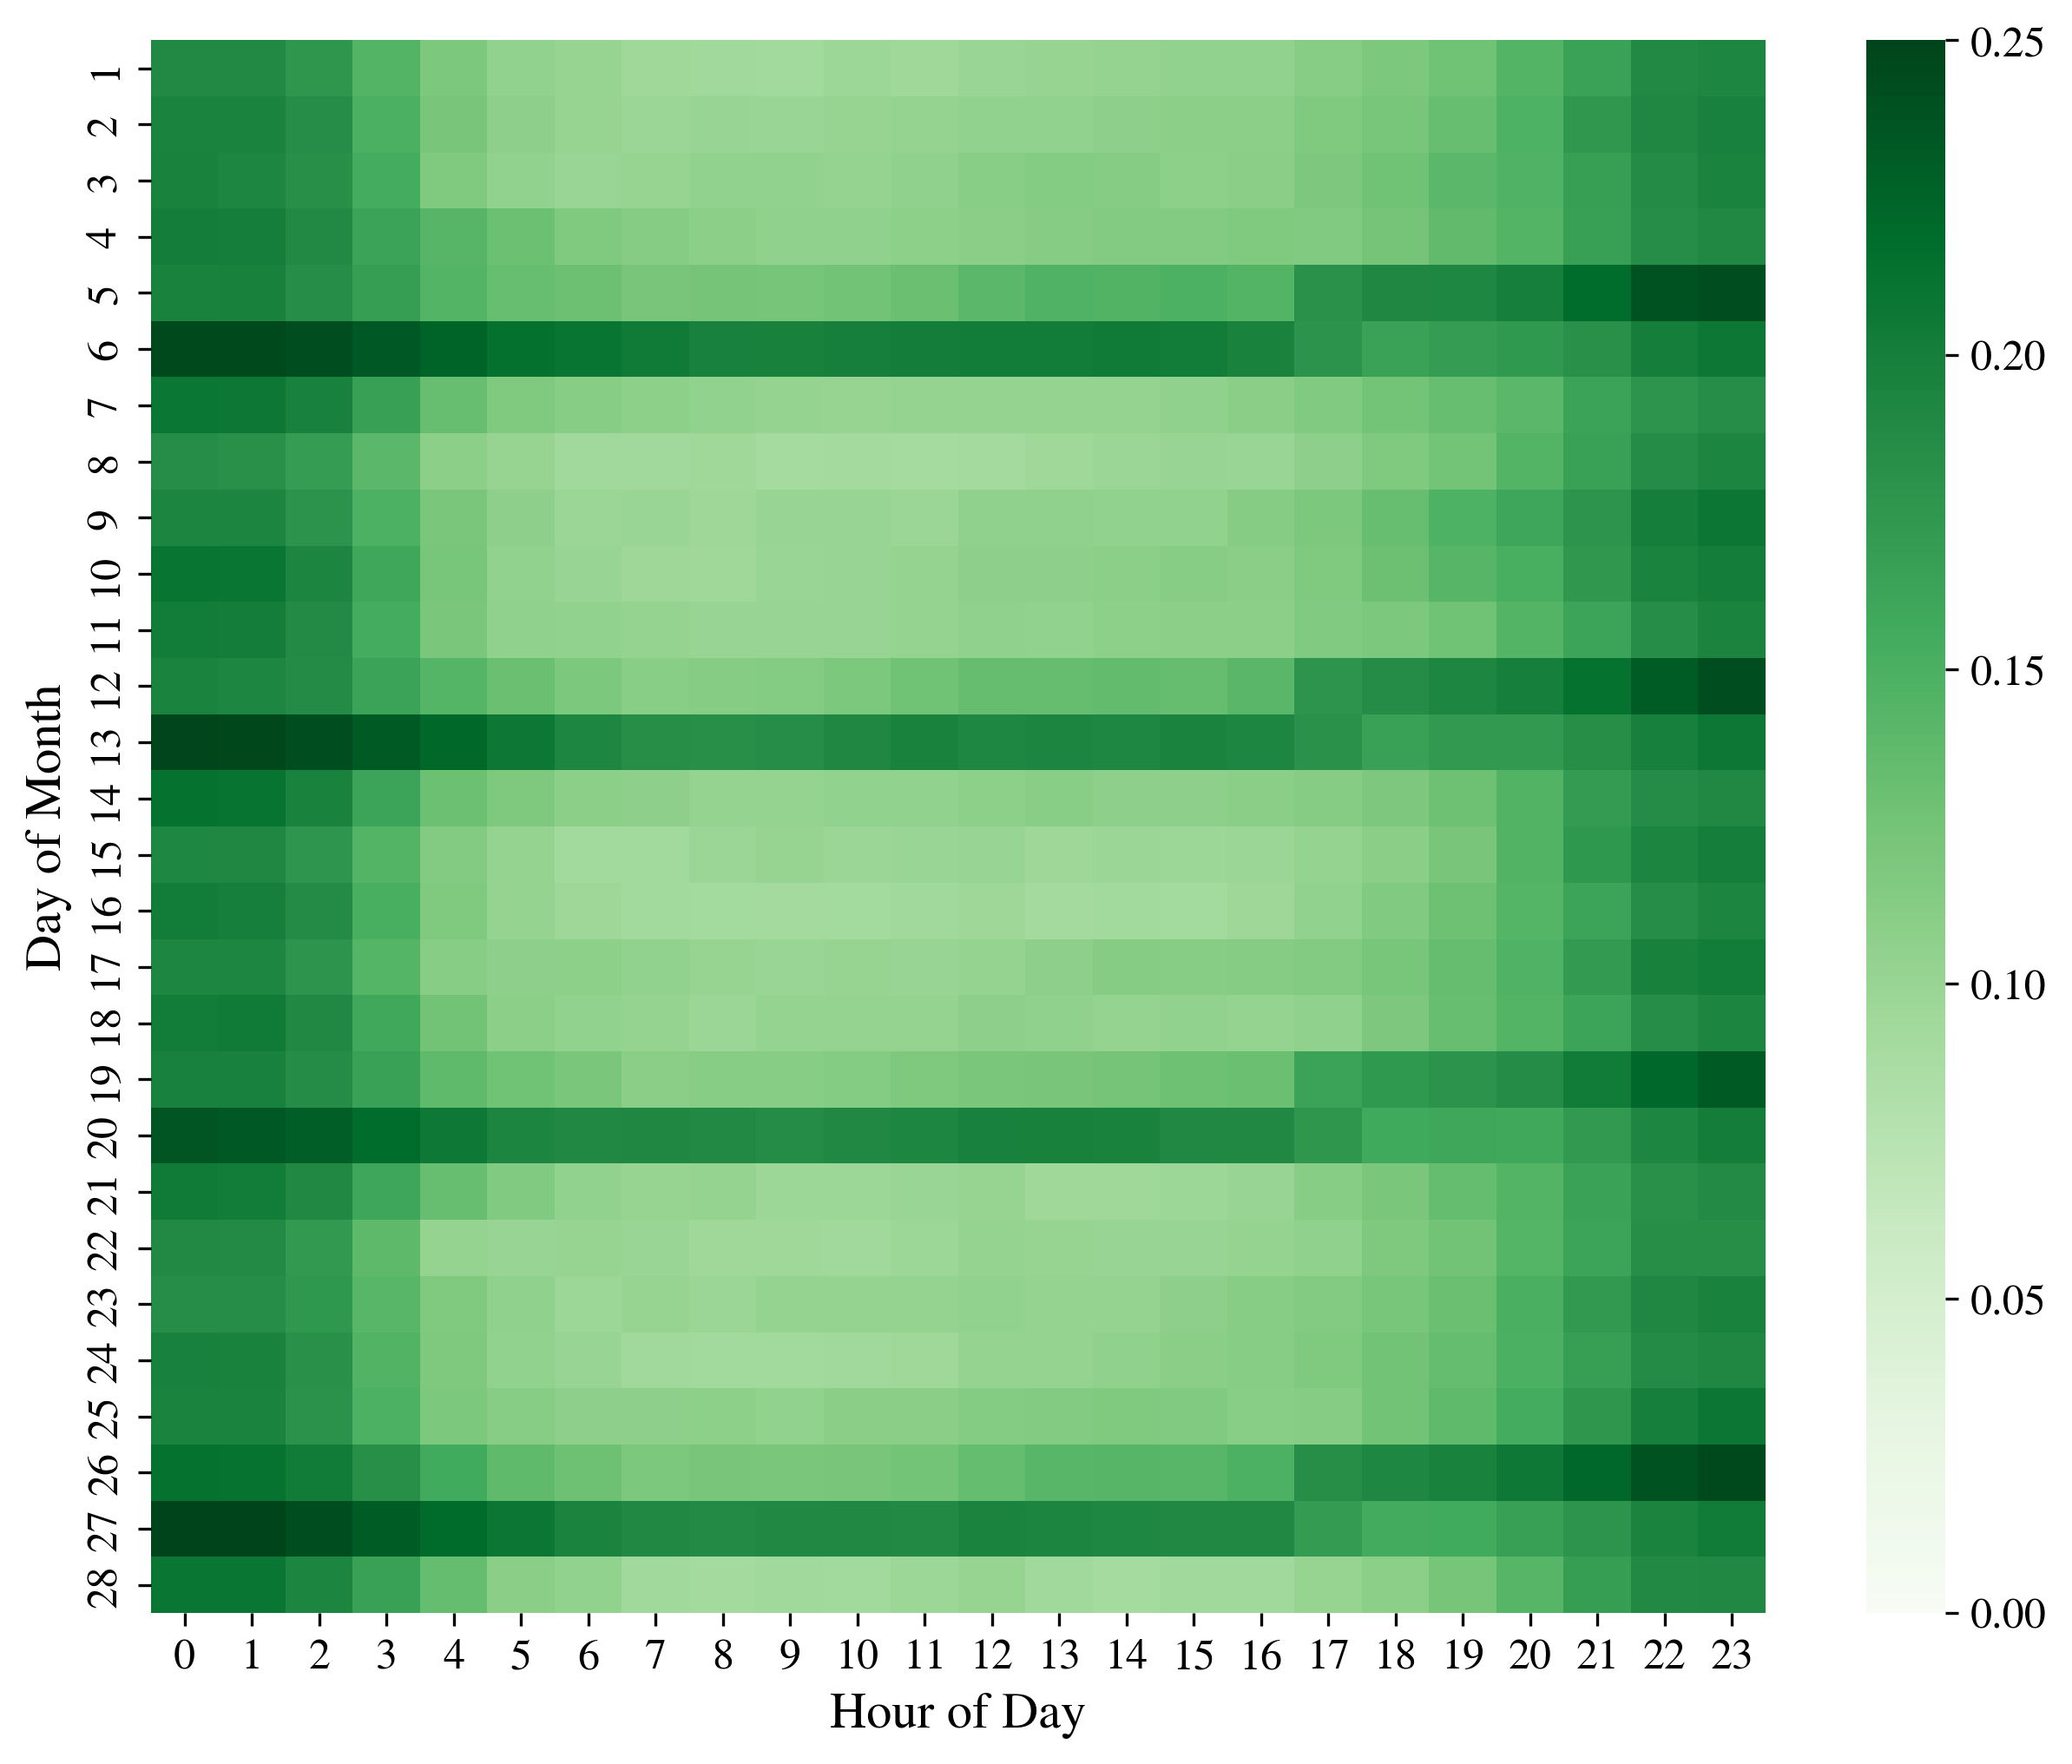

In [17]:
# ----- Missing Data Pattern Visualization -----

mask_list = []

for key in binary_d:
    # Convert the mask to a NumPy array of float type (True -> 1, False -> 0)
    mask = np.array(binary_d[key], dtype=float)
    try:
        mask_reshaped = mask.reshape((28, 24))
    except Exception as e:
        print(f"Key {key} could not be reshaped to (28,24): {e}")
        continue
    mask_list.append(mask_reshaped)

# Compute the average missing data pattern
avg_missing_pattern = np.mean(np.stack(mask_list, axis=0), axis=0)

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
fig.patch.set_alpha(0)    # Set figure background to transparent
ax.set_facecolor("none")  # Set axis background to transparent

sns.heatmap(avg_missing_pattern, cmap="Greens", annot=False, fmt=".2f", vmin=0, vmax=0.25, ax=ax)

# Adjust y-axis to start from 1 instead of 0
plt.yticks(ticks=np.arange(0.5, 28.5, 1), labels=np.arange(1, 29))

plt.xlabel("Hour of Day")
plt.ylabel("Day of Month")
#plt.title("Average Missing Probability")

# Save as SVG with transparent background
#plt.savefig("Figure_Missing_data_pattern_Heatmap.svg", dpi=600, format="svg", transparent=True)

plt.show()

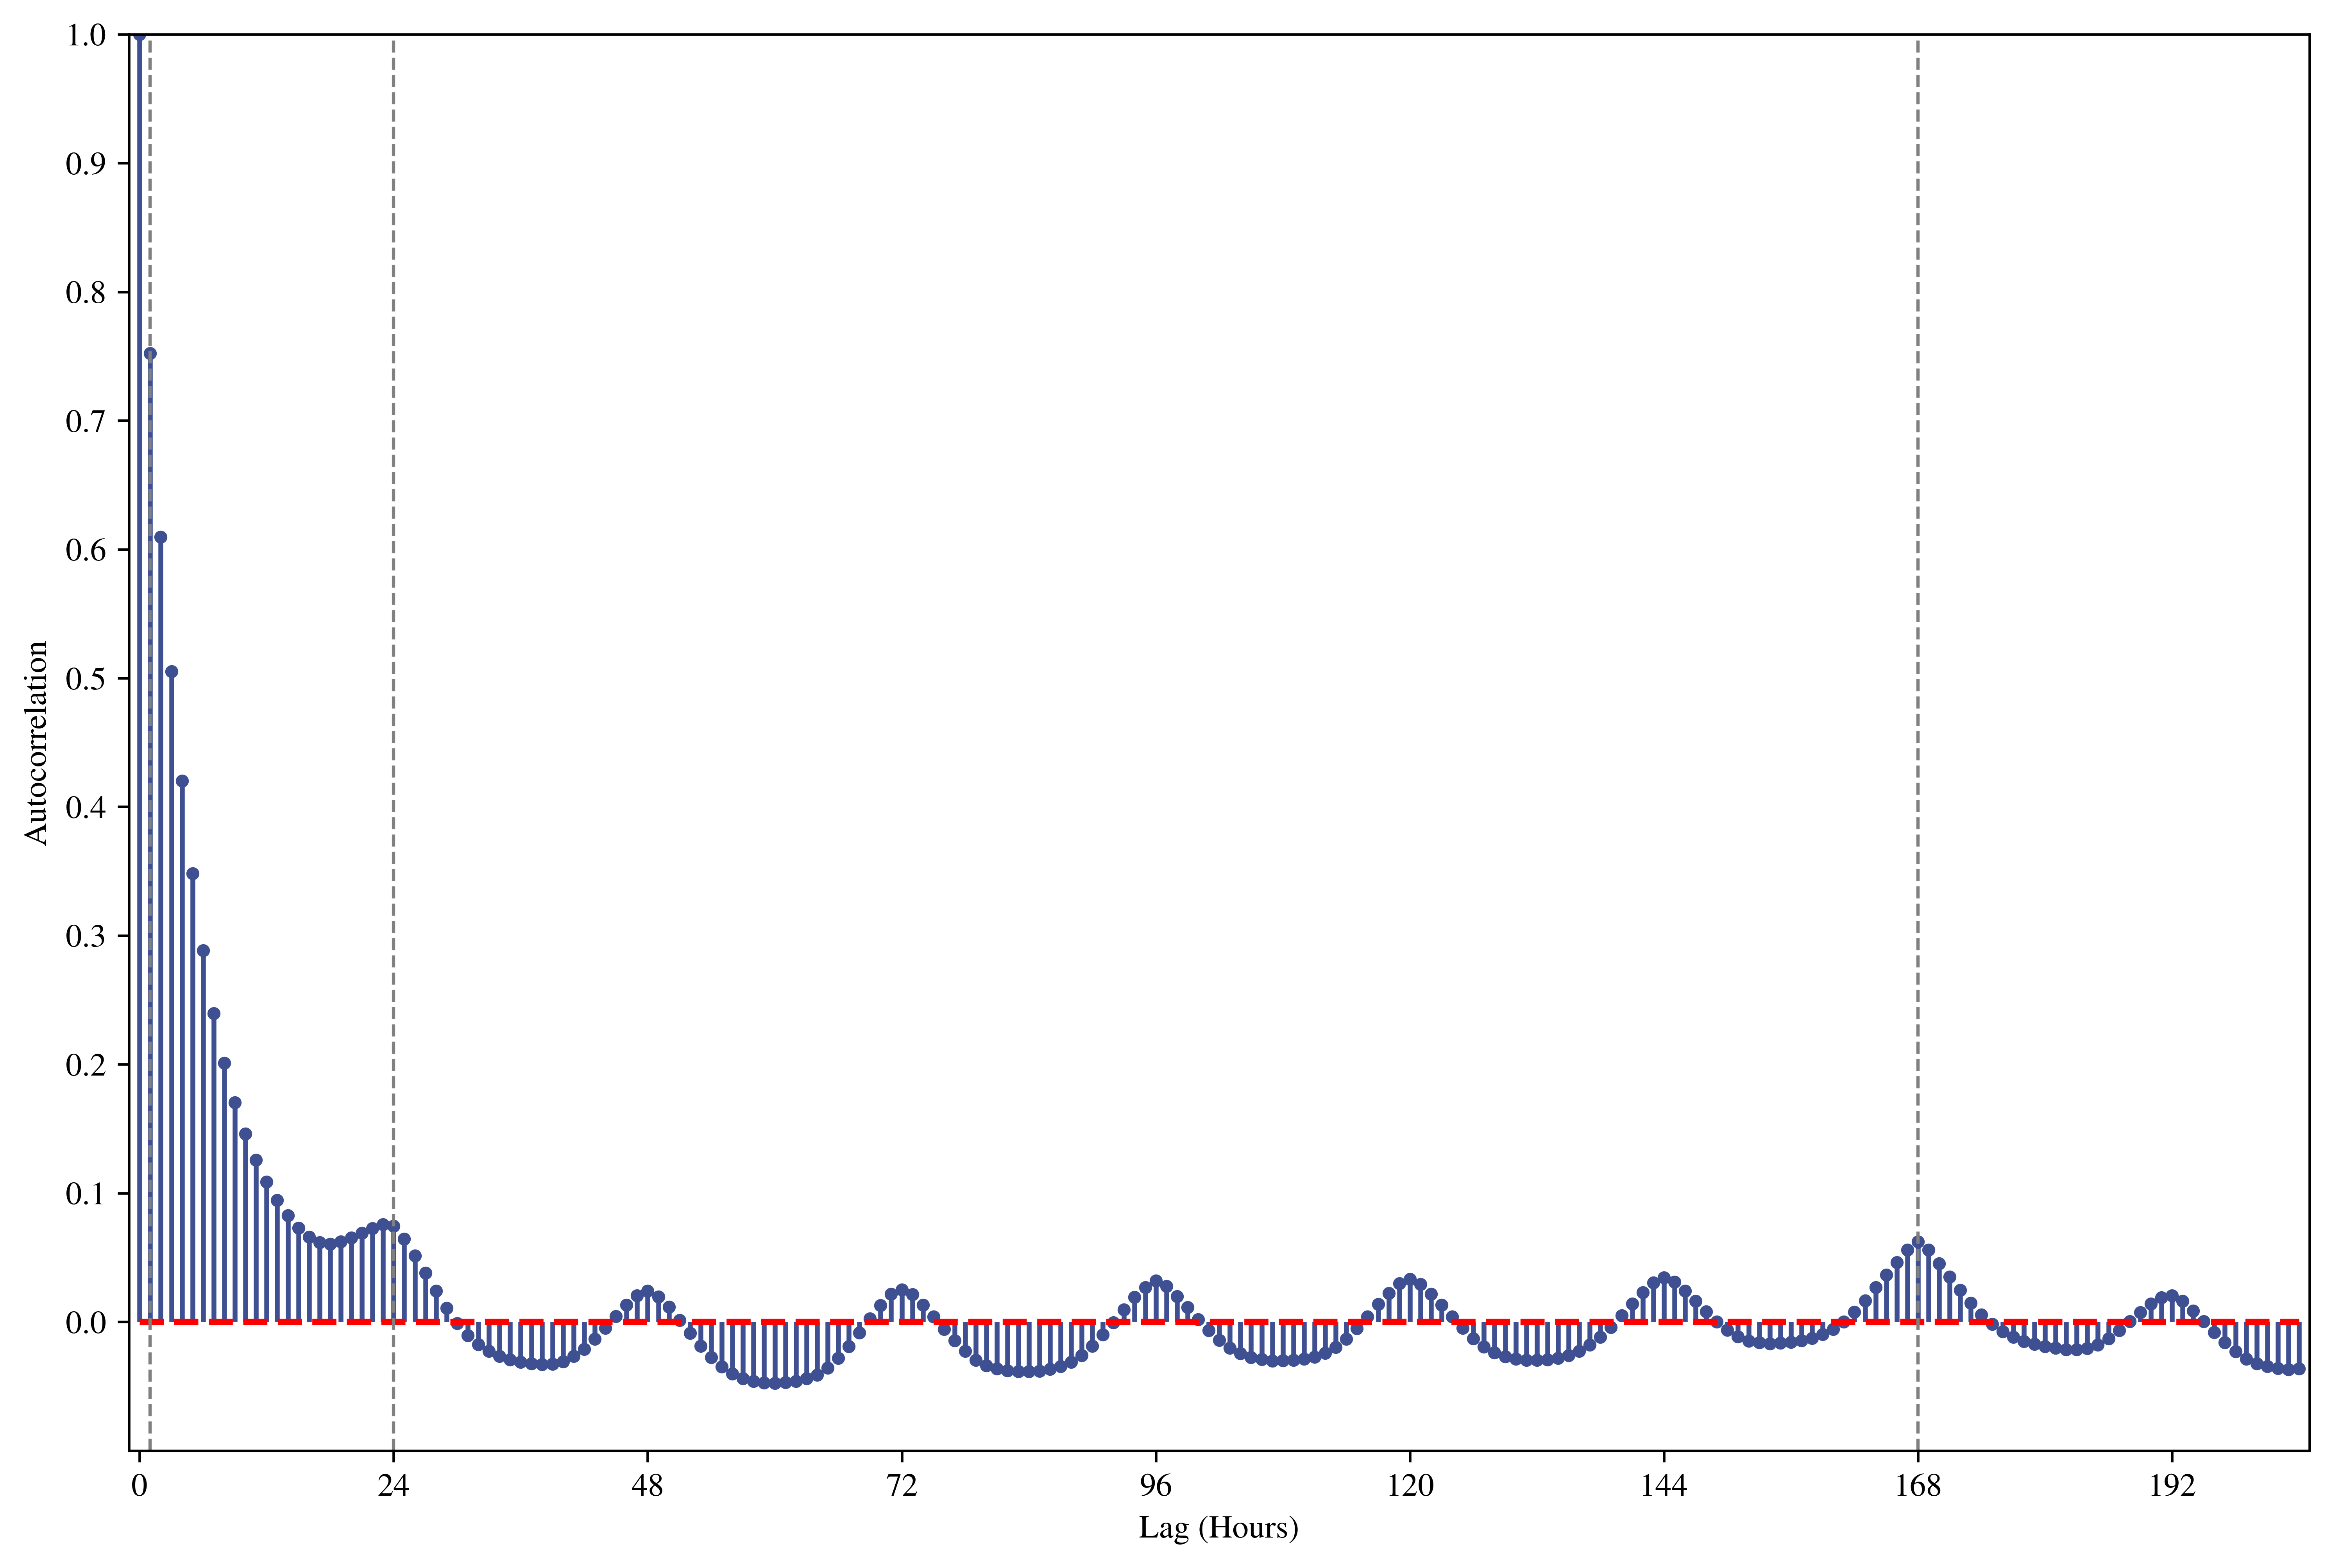

In [37]:
max_lag = 204
missing_acf_values_list = []

# Compute the ACF for the missing data indicator for each subject-month key in binary_d.
for key in binary_d:
    # Convert the missing data boolean mask to integers (1 for missing, 0 for observed)
    missing_series = binary_d[key].flatten().astype(int)
    
    # Ensure the series is long enough for the desired number of lags.
    if len(missing_series) < (max_lag + 1):
        continue

    # Check if the series is constant (all values identical) to avoid division errors.
    if np.all(missing_series == missing_series[0]):
        # Skip this series because acf would be undefined (zero variance).
        continue

    # Compute the ACF for this missing data series, using a try/except to catch issues.
    try:
        acf_vals = acf(missing_series, nlags=max_lag, fft=True)
        # If any computed acf value is NaN, skip this series.
        if np.isnan(acf_vals).any():
            continue
        missing_acf_values_list.append(acf_vals)
    except Exception as e:
        print(f"Error computing ACF for key {key}: {e}")
        continue

if not missing_acf_values_list:
    print("No valid ACF values computed. Check your data for issues.")
else:
    # Compute the mean ACF across all subject-month keys.
    missing_acf_array = np.array(missing_acf_values_list)
    mean_missing_acf = np.mean(missing_acf_array, axis=0)
    lags = np.arange(len(mean_missing_acf))

    # Plot the mean missing data ACF using a stem plot without the deprecated parameter.
    plt.figure(figsize=(12, 8), dpi=600)
    markerline, stemlines, baseline = plt.stem(lags, mean_missing_acf)
    
    markerline.set_markersize(3)               # Set the marker size to 3
    markerline.set_markerfacecolor('#3E5092')  # Set the fill color of the markers
    markerline.set_markeredgecolor('#3E5092')  # Set the marker outline color
    markerline.set_marker('o')                 # Set the marker shape to circle

    stemlines.set_color('#3E5092')             # Set the color for each stem line
    stemlines.set_linewidth(1.5)
    
    baseline.set_color('red')                  # Change the color of the baseline to red
    baseline.set_linewidth(2)                  # Increase the linewidth
    baseline.set_linestyle('--')               # Change the style to dashed

    plt.xlabel("Lag (Hours)")
    plt.ylabel("Autocorrelation")
    #plt.title("Mean ACF of Missing Data Pattern Across Subjects")

    # Set y-axis: from 0 to 1 with interval of 0.1
    plt.ylim(-0.1, 1)
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Set x-axis: from 0 to 200 with interval of 24
    plt.xlim(-1, 205)
    plt.xticks(np.arange(0, 205, 24))

    # Add vertical dashed lines
    for v in [1, 24, 168]:
        plt.axvline(x=v, color='gray', linestyle='--', linewidth=1)
    
    #plt.savefig("Figure_Missing_data_pattern_ACF.svg", dpi=600, format="svg", transparent=True)
    plt.show()

# PMSI

## 2D Function

In [27]:
# ------------------------------------------------------------
# 2D Convolution Imputation Function
# ------------------------------------------------------------
# Global cache for 2D kernels
kernels_cache_2d = {}

def convolution_imputation_2D(img, x_stddev, y_stddev=None, x_size=3, y_size=3, pad_width=3):
    """
    Interpolates missing values in a 2D array (image) using convolution with a Gaussian kernel.
    
    Args:
        img: 2D array with NaN values.
        x_stddev: Standard deviation along x-axis.
        y_stddev: Standard deviation along y-axis (if None, set equal to x_stddev).
        x_size: Kernel window size along x-axis.
        y_size: Kernel window size along y-axis.
        pad_width: Padding width (will be recalculated as half of max(x_size, y_size)).
        
    Returns:
        2D array with NaNs replaced.
    """
    if y_stddev is None:
        y_stddev = x_stddev

    # Create a key for caching the kernel
    k = (x_stddev, y_stddev, x_size, y_size)
    if k not in kernels_cache_2d:
        kernels_cache_2d[k] = Gaussian2DKernel(x_stddev=x_stddev, y_stddev=y_stddev, x_size=x_size, y_size=y_size)
    
    # Recalculate pad width as half of maximum kernel size
    pad_width = max(x_size, y_size) // 2
    padded = np.pad(img.copy(), mode='edge', pad_width=pad_width)
    interpolated = interpolate_replace_nans(padded, kernels_cache_2d[k])
    # Remove padding
    return interpolated[pad_width:-pad_width, pad_width:-pad_width]

In [28]:
# ------------------------------------------------------------
# 2D Optimization Function (computing both AIC and RMSE)
# ------------------------------------------------------------
def optimization_2D(weights):
    tmp_aic_list = []
    tmp_rmse_list = []
    
    # Generate evaluation pairs (10 copies for each good_k paired with a random mask)
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=10 * len(good_k))))
    
    for pair in pairs:
        # Get original complete data and reshape to (28, 24)
        # 28 days (rows) by 24 hours (columns)
        # x-axis (columns) correspond to the hourly (time‐of‐day) pattern
        # y-axis (rows) correspond to the day-to-day (daily/weekly) pattern
        orig = pivot_d[pair[0]].drop(["week_start"], axis=1).values
        orig_array = orig.flatten()
        try:
            orig_2d = orig_array.reshape((28, 24))
        except Exception:
            continue
        
        # Create missing data version
        missing = orig.copy()
        missing[binary_d[pair[1]]] = np.NaN
        try:
            missing_2d = missing.flatten().reshape((28, 24))
        except Exception:
            continue
        
        missing_indices = np.isnan(missing_2d)
        n = np.sum(missing_indices)
        if n == 0:
            continue
        
        # Perform 2D imputation
        imputed_2d = convolution_imputation_2D(
            missing_2d,
            x_stddev=weights["x"],
            y_stddev=weights["y"],
            x_size=X_size,
            y_size=Y_size,
            pad_width=Pad_width
        )
        
        imputed_values = imputed_2d[missing_indices]
        actual_values = orig_2d[missing_indices]
        residuals = imputed_values - actual_values
        
        # Compute RSS and safeguard against division by zero.
        rss = np.sum(residuals**2)
        rss = max(rss, 1e-12)
        log_likelihood = -0.5 * n * np.log(rss / n)
        k_param = 2 
        aic = 2 * k_param - 2 * log_likelihood
        rmse = np.sqrt(np.mean(residuals**2))
        
        tmp_aic_list.append(aic)
        tmp_rmse_list.append(rmse)
    
    if len(tmp_aic_list) == 0:
        return {'loss': 1e10, 'aic': 1e10, 'rmse': 1e10, 'status': STATUS_OK}
    
    avg_aic = np.mean(tmp_aic_list)
    avg_rmse = np.mean(tmp_rmse_list)
    return {'loss': avg_aic, 'aic': avg_aic, 'rmse': avg_rmse, 'status': STATUS_OK}

In [108]:
# ------------------------------------------------------------
# Global constants for 2D imputation
# ------------------------------------------------------------
X_size = 13
Y_size = 13
Pad_width = max(X_size, Y_size) // 2

In [109]:
# ------------------------------------------------------------
# Hyperparameter Search for 2D
# ------------------------------------------------------------
hp_space_2d = {
    'x': hp.uniform('x', 0.1, 5),
    'y': hp.uniform('y', 0.1, 5)
}

## 2D Optimization

In [111]:
# -----------------------------------------------------------------------------
# Run the hyperparameter optimization
# -----------------------------------------------------------------------------
# Set a fixed random seed for reproducibility
SEED = 134
np.random.seed(SEED)  # Seed NumPy's RNG
random.seed(SEED)  # Seed Python's built-in random module

n_evals = 300
trls_2d = Trials()

optim_2d = fmin(
    fn=optimization_2D,
    space=hp_space_2d,
    algo=tpe.suggest,
    trials=trls_2d,
    max_evals=n_evals,
    rstate=np.random.default_rng(SEED)
)

100%|█████████| 300/300 [06:59<00:00,  1.40s/trial, best loss: 172.91474249100992]


In [55]:
best_trial_2d = min(trls_2d.results, key=lambda x: x['loss'])
print("Optimal hyperparameters (2D):", optim_2d)
print("Optimal AIC (2D):", best_trial_2d['aic'])
print("Optimal RMSE (2D):", best_trial_2d['rmse'])

Optimal hyperparameters (2D): {'x': 0.7023111040147278, 'y': 3.857834291617052}
Optimal AIC (2D): 172.91474249100992
Optimal RMSE (2D): 8.820260485127074


In [112]:
SEED = 134
np.random.seed(SEED)
random.seed(SEED)
n_evals = 300
trls_2d = Trials()

with ResourceTracker() as rt_hp:
    optim_2d = fmin(
        fn=optimization_2D,
        space=hp_space_2d,
        algo=tpe.suggest,
        trials=trls_2d,
        max_evals=n_evals,
        rstate=np.random.default_rng(SEED),
    )

# ---- Report -----------------------------------------------------------------
print(f"\n{'='*60}")
print("  HYPERPARAMETER OPTIMIZATION (Conv2D)")
print(f"{'='*60}")
print(f"  n_evals:            {n_evals}")
print(f"  Wall-clock runtime: {rt_hp.elapsed_sec:9.3f} s   "
      f"({rt_hp.elapsed_sec/n_evals*1000:.2f} ms/eval)")
print(f"  Peak Python memory: {rt_hp.peak_python_mb:9.3f} MB  (tracemalloc)")
print(f"  RSS delta:          {rt_hp.rss_delta_mb:9.3f} MB  (psutil)")
print(f"  Best params:        {optim_2d}")
print(f"  Best loss:          {min(trls_2d.losses()):.6f}")

100%|█████████| 300/300 [07:09<00:00,  1.43s/trial, best loss: 172.91474249100992]

  HYPERPARAMETER OPTIMIZATION (Conv2D)
  n_evals:            300
  Wall-clock runtime:   429.795 s   (1432.65 ms/eval)
  Peak Python memory:     1.045 MB  (tracemalloc)
  RSS delta:              0.000 MB  (psutil)
  Best params:        {'x': 0.7023111040147278, 'y': 3.857834291617052}
  Best loss:          172.914742


## Boostrapping

In [54]:
def bootstrap_rmse_2D(weights, n_bootstrap=1000, seed=568):  
    
    # Set random seed for reproducibility.
    random.seed(seed)
    np.random.seed(seed)
    
    boot_rmse_all = []  # To store bootstrapped RMSE values
    best_imputed = None
    best_rmse = np.inf
    
    # Generate evaluation pairs: 10 copies of each good_k paired with a random binary mask.
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=10 * len(good_k))))
    
    for pair in pairs:
        # Retrieve the complete (original) hourly data and flatten it.
        orig = pivot_d[pair[0]].drop(["week_start"], axis=1).values
        orig_array = orig.flatten()
        try:
            # Reshape into a 2D array; here 28 rows (days) and 24 columns (hours)
            orig_2d = orig_array.reshape((28, 24))
        except Exception:
            continue
        
        # Create missing-data version using the binary mask.
        missing = orig.copy()
        missing[binary_d[pair[1]]] = np.NaN
        try:
            missing_2d = missing.flatten().reshape((28, 24))
        except Exception:
            continue
        
        missing_indices = np.isnan(missing_2d)
        n_missing = np.sum(missing_indices)
        if n_missing == 0:
            continue
        
        # Perform 2D imputation using your convolution_imputation_2D function.
        imputed_2d = convolution_imputation_2D(
            missing_2d,
            x_stddev=weights["x"],
            y_stddev=weights["y"],
            x_size=X_size,
            y_size=Y_size,
            pad_width=Pad_width
        )
        
        imputed_values = imputed_2d[missing_indices]
        actual_values = orig_2d[missing_indices]
        residuals = imputed_values - actual_values
        
        # Bootstrap: resample the residuals with replacement to compute RMSE.
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(residuals), size=len(residuals), replace=True)
            boot_sample = residuals[sample_indices]
            boot_rmse = np.sqrt(np.mean(boot_sample**2))
            boot_rmse_all.append(boot_rmse)
    
    # Compute mean and standard deviation of the bootstrapped RMSE values.
    boot_rmse_all = np.array(boot_rmse_all)
    mean_rmse = np.mean(boot_rmse_all)
    std_rmse = np.std(boot_rmse_all)

    return mean_rmse, std_rmse, boot_rmse_all

In [27]:
# -------------------------------------------------------------------------
optimal_weights_2d = {'x': optim_2d['x'], 'y': optim_2d['y']}

# Compute bootstrapped RMSE values for the 2D imputation method
mean_rmse_2d, std_rmse_2d, boot_rmse_values_2d = bootstrap_rmse_2D(optimal_weights_2d, n_bootstrap=10000, seed=108)

np.save("new_boot_rmse_values_2d.npy", np.array(boot_rmse_values_2d))

## 2D Results

In [32]:
boot_rmse_values_2d = np.load("boot_rmse_values_2d.npy")

mean_rmse_2d = np.mean(boot_rmse_values_2d)
std_rmse_2d = np.std(boot_rmse_values_2d)

In [33]:
print("Bootstrapped RMSE Mean:", mean_rmse_2d)
print("Bootstrapped RMSE Standard Deviation:", std_rmse_2d)

Bootstrapped RMSE Mean: 6.673262803895582
Bootstrapped RMSE Standard Deviation: 4.262761796873763


In [60]:
# ----------------------------
# LOCF Imputation Function for 1D
# ----------------------------
def locf_imputation_1D(array):
    """
    Impute missing values in a 1D array using forward fill followed by backward fill.
    
    Args:
        array: 1D numpy array with NaN values.
        
    Returns:
        1D numpy array with NaN values imputed.
    """
    s = pd.Series(array)
    s_filled = s.fillna(method='ffill').fillna(method='bfill')
    return s_filled.values

#### Archive

In [66]:
# ----------------------------
# Bootstrapped RMSE Calculation for 1D LOCF
# ----------------------------
def bootstrap_rmse_locf_1D(n_bootstrap=1000, seed=1128):
    # Set random seed for reproducibility (for bootstrapping)
    random.seed(seed)
    np.random.seed(seed)
    
    boot_rmse_all = []  # To store bootstrapped RMSE values
    best_imputed = None
    best_rmse = np.inf
    
    # Generate evaluation pairs: 10 copies for each good_k paired with a random binary mask
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=10 * len(good_k))))
    
    for pair in pairs:
        # Extract original complete hourly data and flatten
        orig = pivot_d[pair[0]].drop(["week_start"], axis=1).values.flatten()
        # Create a copy and apply the binary mask to set missing values as NaN
        missing = orig.copy()
        # Make sure the mask is 1D and has the same length as orig:
        missing[np.where(binary_d[pair[1]].flatten())] = np.NaN
        
        # Perform LOCF imputation
        imputed = locf_imputation_1D(missing)
        
        # Identify indices where data is missing (to compare imputed vs. actual)
        missing_indices = np.isnan(missing)
        n_missing = np.sum(missing_indices)
        if n_missing == 0:
            continue
        
        imputed_values = imputed[missing_indices]
        actual_values = orig[missing_indices]
        residuals = imputed_values - actual_values
        
        # Bootstrap the residuals to compute RMSE distribution
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(residuals), size=len(residuals), replace=True)
            boot_sample = residuals[sample_indices]
            boot_rmse = np.sqrt(np.mean(boot_sample**2))
            boot_rmse_all.append(boot_rmse)
        
    # Compute mean and standard deviation of the bootstrapped RMSE values.
    boot_rmse_all = np.array(boot_rmse_all)
    mean_rmse = np.mean(boot_rmse_all)
    std_rmse = np.std(boot_rmse_all)

    return mean_rmse, std_rmse, boot_rmse_all

In [238]:
# ----------------------------
# LOCF Imputation
# ----------------------------
mean_rmse_locf, std_rmse_locf, boot_rmse_values_locf = bootstrap_rmse_locf_1D(n_bootstrap=10000, seed=1128)

np.save("boot_rmse_values_locf.npy", np.array(boot_rmse_values_locf))

In [34]:
boot_rmse_values_locf = np.load("boot_rmse_values_locf.npy")

mean_rmse_locf = np.mean(boot_rmse_values_locf)
std_rmse_locf = np.std(boot_rmse_values_locf)

In [7]:
print("Bootstrapped RMSE Mean:", mean_rmse_locf)
print("Bootstrapped RMSE Standard Deviation:", std_rmse_locf)

Bootstrapped RMSE Mean: 9.619932836232595
Bootstrapped RMSE Standard Deviation: 6.475225605037368


### LOCF Results

In [61]:
def bootstrap_rmse_ci_locf(pivot_d, binary_d, good_k, binary_masks,
                           n_replicates=1000, seed=42):
    """
    Bootstraps per-pair RMSEs for LOCF imputation in 1D and returns
    (rmse_arr, mean_rmse, lower_95_CI, upper_95_CI).
    """
    random.seed(seed)
    np.random.seed(seed)
    
    # Rebuild the same evaluation pairs: 10× each complete key with random mask
    N = len(good_k) * 10
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=N)))
    
    # Compute one RMSE per pair
    rmse_list = []
    for orig_key, mask_key in pairs:
        # Original complete data flattened
        flat = pivot_d[orig_key].drop(["week_start"], axis=1).values.flatten()
        
        # Create missing version
        miss = flat.copy()
        miss[binary_d[mask_key].flatten().astype(bool)] = np.nan
        
        # Impute via LOCF
        imputed = locf_imputation_1D(miss)
        
        # Compute RMSE on masked indices
        mask = np.isnan(miss)
        if mask.sum() == 0:
            continue
        residuals = imputed[mask] - flat[mask]
        rmse_list.append(np.sqrt(np.mean(residuals**2)))
    
    rmse_arr = np.array(rmse_list)
    mean_rmse = rmse_arr.mean()
    
    # Bootstrap sampling of the mean RMSE
    boot_means = np.empty(n_replicates)
    for i in range(n_replicates):
        sample = np.random.choice(rmse_arr, size=rmse_arr.size, replace=True)
        boot_means[i] = sample.mean()
    
    lower, upper = np.percentile(boot_means, [2.5, 97.5])
    return rmse_arr, mean_rmse, lower, upper

# -----------------------
# USAGE EXAMPLE:
# Compute and print the per-pair RMSEs and bootstrap CI for LOCF
rmse_locf_arr, mean_rmse_locf, lo95_locf, hi95_locf = bootstrap_rmse_ci_locf(
    pivot_d, binary_d, good_k, binary_masks,
    n_replicates=10000,
    seed=2025
)

print(f"Per-pair RMSEs (LOCF): {rmse_locf_arr.shape[0]} values")
print(f"Bootstrap mean RMSE (LOCF): {mean_rmse_locf:.4f}")
print(f"95% CI for RMSE         : [{lo95_locf:.4f}, {hi95_locf:.4f}]")

Per-pair RMSEs (LOCF): 600 values
Bootstrap mean RMSE (LOCF): 12.9869
95% CI for RMSE         : [12.5126, 13.4777]


### Dual points

In [62]:
# --------------------------------------------------
# Piecewise Linear Interpolation Imputation for 1D
# --------------------------------------------------
def piecewise_linear_imputation_1D(array):
    """
    Impute missing values in a 1D array using piecewise linear interpolation.
    First, the method performs linear interpolation. Then, in case the
    beginning or end remain missing, it applies forward and backward fill.
    
    Args:
        array: 1D numpy array with NaN values.
        
    Returns:
        1D numpy array with missing values imputed.
    """
    s = pd.Series(array)
    s_interp = s.interpolate(method='linear')
    # In case there are still NaNs at the beginning or end, fill them.
    s_interp = s_interp.fillna(method='ffill').fillna(method='bfill')
    return s_interp.values

### Multiple Points

#### PLI Functions

In [63]:
def multi_point_linear_imputation_1D(array, window_size=7):
    """
    Impute missing values in a 1D array using a local linear regression 
    over multiple surrounding observed points.
    
    For each missing value, the function selects observed points within a 
    window (from max(0, i-window_size) to min(n, i+window_size+1)). If at 
    least two points are available, a linear regression is performed using 
    np.polyfit to determine slope and intercept, and the missing value is 
    imputed as: value = slope * index + intercept.
    
    After processing each missing value, any remaining NaNs are filled using 
    forward-fill then backward-fill.
    
    Parameters:
        array : 1D numpy array with missing values (NaN).
        window_size : int, optional (default=5)
            Number of indices to consider on each side of the missing value.
    
    Returns:
        imputed : 1D numpy array with missing values imputed.
    """
    arr = np.array(array, copy=True)
    n = len(arr)
    
    # Iterate over each index.
    for i in range(n):
        if np.isnan(arr[i]):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)
            # Collect indices and values that are not NaN in the window.
            obs_idx = []
            obs_vals = []
            for j in range(left, right):
                if not np.isnan(arr[j]):
                    obs_idx.append(j)
                    obs_vals.append(arr[j])
            if len(obs_idx) >= 2:
                # Fit a linear model (degree 1 polynomial) to the observed points.
                slope, intercept = np.polyfit(obs_idx, obs_vals, 1)
                arr[i] = slope * i + intercept
            # Otherwise, leave arr[i] as NaN (it will be filled later).
    
    # Fill any remaining NaNs with forward then backward fill.
    s = pd.Series(arr)
    s_filled = s.fillna(method='ffill').fillna(method='bfill')
    return s_filled.values

##### Archive

In [68]:
# --------------------------------------------------
# Bootstrapped RMSE Calculation for 1D Piecewise Linear Interpolation
# --------------------------------------------------
def bootstrap_rmse_multi_point_linear_1D(n_bootstrap=1000, seed=1128, window_size=5):
    random.seed(seed)
    np.random.seed(seed)
    
    boot_rmse_all = []
    best_imputed = None
    best_rmse = np.inf

    # Generate evaluation pairs: 10 copies of each good key paired with a random binary mask.
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=10 * len(good_k))))
    
    for pair in pairs:
        # Retrieve the complete hourly series and flatten.
        orig = pivot_d[pair[0]].drop(["week_start"], axis=1).values.flatten()
        missing = orig.copy()
        # Apply the binary mask (flattened) to create missing values.
        missing[np.where(binary_d[pair[1]].flatten())] = np.NaN

        # Impute missing values using multi-point linear interpolation.
        imputed = multi_point_linear_imputation_1D(missing, window_size=window_size)
        
        # Identify indices where data was missing.
        missing_indices = np.isnan(missing)
        n_missing = np.sum(missing_indices)
        if n_missing == 0:
            continue
        
        imputed_values = imputed[missing_indices]
        actual_values = orig[missing_indices]
        residuals = imputed_values - actual_values
        
        # Bootstrap: resample the residuals with replacement and compute RMSE.
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(residuals), size=len(residuals), replace=True)
            boot_sample = residuals[sample_indices]
            boot_rmse = np.sqrt(np.mean(boot_sample**2))
            boot_rmse_all.append(boot_rmse)
        
    # Compute mean and standard deviation of the bootstrapped RMSE values.
    boot_rmse_all = np.array(boot_rmse_all)
    mean_rmse = np.mean(boot_rmse_all)
    std_rmse = np.std(boot_rmse_all)

    return mean_rmse, std_rmse, boot_rmse_all

In [243]:
# --------------------------------------------------
# 1D Piecewise Linear Interpolation Imputation
# --------------------------------------------------
mean_rmse_multi, std_rmse_multi, boot_rmse_values_multi = bootstrap_rmse_multi_point_linear_1D(n_bootstrap=10000, seed=1128, window_size=7)

np.save("boot_rmse_values_multi.npy", np.array(boot_rmse_values_multi))

In [35]:
boot_rmse_values_multi = np.load("boot_rmse_values_multi.npy")

mean_rmse_multi = np.mean(boot_rmse_values_multi)
std_rmse_multi = np.std(boot_rmse_values_multi)

In [9]:
print("Bootstrapped RMSE Mean:", mean_rmse_multi)
print("Bootstrapped RMSE Standard Deviation:", std_rmse_multi)

Bootstrapped RMSE Mean: 9.525134108452901
Bootstrapped RMSE Standard Deviation: 5.770426601540866


In [65]:
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# --------------------------------------------------
# autoARIMA Imputation Function for 1D Data
# --------------------------------------------------
def autoarima_imputation_1D(array):
    """
    Impute missing values in a 1D array using autoARIMA to select the best order.
    
    The function first fills missing values using forward/backward fill
    to obtain an initial series for model fitting. Then, auto_arima selects
    the best ARIMA model. Finally, in-sample predictions replace only the missing entries.
    
    Args:
        array: 1D numpy array with NaNs.
        
    Returns:
        imputed: 1D numpy array with missing values replaced by ARIMA predictions.
    """
    s = pd.Series(array)
    # Initial fill for model fitting
    initial = s.fillna(method='ffill').fillna(method='bfill').values
    try:
        # auto_arima selects the best model order automatically.
        model = auto_arima(initial, error_action='ignore', suppress_warnings=True, stepwise=True)
        # Get in-sample predictions for all time steps.
        predicted = model.predict_in_sample()
    except Exception as e:
        print("autoARIMA fit failed:", e)
        return initial
    imputed = np.array(array)
    # Replace only missing values with predictions.
    imputed[np.isnan(imputed)] = predicted[np.isnan(imputed)]
    return imputed

#### Archive

In [72]:
# --------------------------------------------------
# Bootstrapped RMSE Calculation for autoARIMA Imputation (1D)
# --------------------------------------------------
def bootstrap_rmse_autoarima_1D(n_bootstrap=1000, seed=1128):
    random.seed(seed)
    np.random.seed(seed)
    
    boot_rmse_all = []
    best_imputed = None
    best_rmse = np.inf
    
    # Create evaluation pairs: use 10 copies of each good_k paired with a random binary mask.
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=10 * len(good_k))))
    
    for pair in pairs:
        # Get the original complete hourly series (flattened).
        orig = pivot_d[pair[0]].drop(["week_start"], axis=1).values.flatten()
        
        # Create missing-data version by applying the binary mask.
        missing = orig.copy()
        # Ensure the mask is 1D (flatten the binary mask)
        mask = binary_d[pair[1]].flatten()
        missing[mask] = np.NaN
        
        # Perform autoARIMA imputation.
        imputed = autoarima_imputation_1D(missing)
        
        # Identify missing indices.
        missing_indices = np.isnan(missing)
        n_missing = np.sum(missing_indices)
        if n_missing == 0:
            continue
        
        imputed_values = imputed[missing_indices]
        actual_values = orig[missing_indices]
        residuals = imputed_values - actual_values
        
        # Bootstrap the residuals.
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(residuals), size=len(residuals), replace=True)
            boot_sample = residuals[sample_indices]
            boot_rmse = np.sqrt(np.mean(boot_sample ** 2))
            boot_rmse_all.append(boot_rmse)
        
    # Compute mean and standard deviation of the bootstrapped RMSE values.
    boot_rmse_all = np.array(boot_rmse_all)
    mean_rmse = np.mean(boot_rmse_all)
    std_rmse = np.std(boot_rmse_all)

    return mean_rmse, std_rmse, boot_rmse_all

In [248]:
# --------------------------------------------------
# autoARIMA Imputation with Bootstrapping (1D)
# --------------------------------------------------
mean_rmse_autoarima, std_rmse_autoarima, boot_rmse_values_autoarima = bootstrap_rmse_autoarima_1D(n_bootstrap=10000, seed=1128)

np.save("boot_rmse_values_autoarima.npy", np.array(boot_rmse_values_autoarima))

In [36]:
boot_rmse_values_autoarima = np.load("boot_rmse_values_autoarima.npy")

mean_rmse_autoarima = np.mean(boot_rmse_values_autoarima)
std_rmse_autoarima = np.std(boot_rmse_values_autoarima)

In [11]:
print("Bootstrapped RMSE Mean:", mean_rmse_autoarima)
print("Bootstrapped RMSE Standard Deviation:", std_rmse_autoarima)

Bootstrapped RMSE Mean: 8.736213029434921
Bootstrapped RMSE Standard Deviation: 5.696501344197345


In [66]:
import random
import numpy as np

def bootstrap_rmse_ci_arima(pivot_d, binary_d, good_k, binary_masks,
                            n_replicates=1000, seed=42):
    """
    Bootstraps per-pair RMSEs for ARIMA-based imputation and returns
    (rmse_arr, mean_rmse, lower_95_CI, upper_95_CI).
    """
    random.seed(seed)
    np.random.seed(seed)
    
    # Rebuild the same evaluation pairs
    N = len(good_k) * 10
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=N)))
    
    rmse_list = []
    for orig_key, mask_key in pairs:
        # Original complete data flattened
        flat = pivot_d[orig_key].drop(["week_start"], axis=1).values.flatten()
        
        # Create missing version
        miss = flat.copy()
        miss[binary_d[mask_key].flatten().astype(bool)] = np.nan
        
        # Impute via autoARIMA
        imputed = autoarima_imputation_1D(miss)
        
        # Compute RMSE on masked indices
        mask = np.isnan(miss)
        if mask.sum() == 0:
            continue
        residuals = imputed[mask] - flat[mask]
        rmse_list.append(np.sqrt(np.mean(residuals**2)))
    
    rmse_arr = np.array(rmse_list)
    mean_rmse = rmse_arr.mean()
    
    # Bootstrap sampling of the mean RMSE
    boot_means = np.empty(n_replicates)
    for i in range(n_replicates):
        sample = np.random.choice(rmse_arr, size=rmse_arr.size, replace=True)
        boot_means[i] = sample.mean()
    
    lower, upper = np.percentile(boot_means, [2.5, 97.5])
    return rmse_arr, mean_rmse, lower, upper

# -----------------------
# USAGE EXAMPLE:
rmse_arima_arr, mean_rmse_arima, lo95_arima, hi95_arima = bootstrap_rmse_ci_arima(
    pivot_d, binary_d, good_k, binary_masks,
    n_replicates=10000,
    seed=42
)

print(f"Per-pair RMSEs (autoARIMA): {rmse_arima_arr.size} values")
print(f"Bootstrap mean RMSE (autoARIMA): {mean_rmse_arima:.4f}")
print(f"95% CI for RMSE              : [{lo95_arima:.4f}, {hi95_arima:.4f}]")

KeyboardInterrupt: 

### KNN Functions

In [166]:
# --------------------------------------------------
# KNN Imputation Function for 2D Data
# --------------------------------------------------
def knn_imputation_2D(arr, n_neighbors, method="distance"):
    """
    Impute missing values in a 2D array using KNN imputation.
    
    This function performs imputation column-wise and row-wise, then averages
    the results.
    
    Args:
        arr: 2D numpy array with missing values (NaNs).
        n_neighbors: Number of nearest neighbors to use.
        method: Weighting method for neighbors ("uniform" or "distance").
    
    Returns:
        2D array with missing values imputed.
    """
    # Initialize KNN imputer
    imputer = KNNImputer(n_neighbors=n_neighbors, weights=method, keep_empty_features=True)
    
    # Impute column-wise
    a = imputer.fit_transform(arr)
    # Impute row-wise (by transposing, imputing, then transposing back)
    b = imputer.fit_transform(arr.T).T
    
    # Replace any zeros in 'a' with corresponding values from 'b' (and vice versa)
    # (This step is heuristic – adjust if your data normally contain zeros.)
    a[np.where(a == 0)] = b[np.where(a == 0)]
    b[np.where(b == 0)] = a[np.where(b == 0)]
    
    mean_arr = (a + b) / 2
    # Optionally, if zeros indicate missingness, convert them back to NaN:
    mean_arr[mean_arr == 0] = np.nan
    
    return mean_arr

#### Archive

In [76]:
# --------------------------------------------------
# Bootstrapped RMSE Calculation for 2D KNN Imputation
# --------------------------------------------------
def bootstrap_rmse_knn_2D(args, n_bootstrap=1000, seed=1128):
    """
    Compute bootstrapped RMSE values for 2D imputation using KNN.
    
    For each evaluation pair (constructed from complete data and a randomly
    chosen binary mask), the function:
      - Reshapes the original hourly data to a 2D array (e.g., 28 days × 24 hours).
      - Applies the mask to create missing values.
      - Imputes missing values using KNN imputation with the given hyperparameters.
      - Computes the residuals (imputed - actual) at missing positions.
      - Bootstraps these residuals (with a fixed seed) to calculate a distribution of RMSE values.
      - Tracks the best imputed result (lowest RMSE) along with its RMSE.
    
    Args:
        args: Dictionary with hyperparameters for KNN, e.g.:
              { "k": number_of_neighbors, "method": "uniform" or "distance" }.
        n_bootstrap: Number of bootstrap samples per evaluation pair.
        seed: Random seed for reproducibility.
    
    Returns:
        boot_rmse_all: List of bootstrapped RMSE values.
        best_rmse: The lowest RMSE observed across all evaluation pairs.
        best_imputed: The imputed 2D array corresponding to the best RMSE.
    """
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    
    boot_rmse_all = []
    best_imputed = None
    best_rmse = np.inf
    
    # Generate evaluation pairs: use 10 copies for each good key, paired with a random mask.
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=10 * len(good_k))))
    
    for pair in pairs:
        # Retrieve the original complete data (hourly data)
        orig = pivot_d[pair[0]].drop(["week_start"], axis=1).values
        orig_array = orig.flatten()
        try:
            # Reshape into a 2D array (e.g., 28 days × 24 hours)
            orig_2d = orig_array.reshape((4, 24*7))
        except Exception:
            continue
        
        # Create the missing-data version using the binary mask.
        missing = orig.copy()
        missing[binary_d[pair[1]]] = np.NaN
        try:
            missing_2d = missing.flatten().reshape((4, 24*7))
        except Exception:
            continue
        
        missing_indices = np.isnan(missing_2d)
        n_missing = np.sum(missing_indices)
        if n_missing == 0:
            continue
        
        # Perform KNN imputation using the provided hyperparameters.
        imputed_2d = knn_imputation_2D(missing_2d, n_neighbors=args["k"], method=args["method"])
        
        imputed_values = imputed_2d[missing_indices]
        actual_values = orig_2d[missing_indices]
        residuals = imputed_values - actual_values
        
        # Bootstrap the residuals.
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(residuals), size=len(residuals), replace=True)
            boot_sample = residuals[sample_indices]
            boot_rmse = np.sqrt(np.mean(boot_sample**2))
            boot_rmse_all.append(boot_rmse)
    
    # Compute mean and standard deviation of the bootstrapped RMSE values.
    boot_rmse_all = np.array(boot_rmse_all)
    mean_rmse = np.mean(boot_rmse_all)
    std_rmse = np.std(boot_rmse_all)

    return mean_rmse, std_rmse, boot_rmse_all

In [252]:
# --------------------------------------------------
# KNN Imputation with Bootstrapping (2D)
# --------------------------------------------------
# Define the hyperparameters for KNN imputation.
optimal_knn_params = {"k": 5, "method": "distance"}

# Compute bootstrapped RMSE values for KNN-based imputation.
mean_rmse_knn, std_rmse_knn, boot_rmse_values_knn = bootstrap_rmse_knn_2D(optimal_knn_params, n_bootstrap=10000, seed=1128)

np.save("boot_rmse_values_knn.npy", np.array(boot_rmse_values_knn))

In [37]:
optimal_knn_params = {"k": 5, "method": "distance"}

boot_rmse_values_knn = np.load("boot_rmse_values_knn.npy")

mean_rmse_knn = np.mean(boot_rmse_values_knn)
std_rmse_knn = np.std(boot_rmse_values_knn)

In [13]:
print("Bootstrapped RMSE Mean:", mean_rmse_knn)
print("Bootstrapped RMSE Standard Deviation:", std_rmse_knn)

Bootstrapped RMSE Mean: 8.241720665232412
Bootstrapped RMSE Standard Deviation: 5.005577384493054


### KNN Results

In [236]:
def bootstrap_rmse_ci_knn2d(pivot_d, binary_d, good_k, binary_masks,
                            n_neighbors, method="distance",
                            n_replicates=1000, seed=42):
    """
    Bootstraps per-pair RMSEs for 2D KNN imputation and returns
    (rmse_arr, mean_rmse, lower_95_CI, upper_95_CI).
    """
    random.seed(seed)
    np.random.seed(seed)

    # Prepare evaluation pairs: 10× each complete key with a random mask
    N = len(good_k) * 10
    pairs = list(zip(10 * good_k, random.choices(binary_masks, k=N)))

    rmse_list = []
    for orig_key, mask_key in pairs:
        # Build original 2D (28×24)
        flat = pivot_d[orig_key].drop(["week_start"], axis=1).values.flatten()
        try:
            orig_2d = flat.reshape((28, 24))
        except ValueError:
            continue

        # Introduce missingness
        miss_flat = flat.copy()
        miss_flat[binary_d[mask_key].flatten().astype(bool)] = np.nan
        try:
            miss_2d = miss_flat.reshape((28, 24))
        except ValueError:
            continue

        mask = np.isnan(miss_2d)
        if mask.sum() == 0:
            continue

        # Impute via KNN
        imputed = knn_imputation_2D(miss_2d, n_neighbors=n_neighbors, method=method)

        # Compute RMSE on masked entries
        residuals = imputed[mask] - orig_2d[mask]
        rmse_list.append(np.sqrt(np.mean(residuals**2)))

    rmse_arr = np.array(rmse_list)
    mean_rmse = rmse_arr.mean()

    # Bootstrap sampling of the mean RMSE
    boot_means = np.empty(n_replicates)
    for i in range(n_replicates):
        sample = np.random.choice(rmse_arr, size=rmse_arr.size, replace=True)
        boot_means[i] = sample.mean()

    lower, upper = np.percentile(boot_means, [2.5, 97.5])
    return rmse_arr, mean_rmse, lower, upper

# -----------------------
# USAGE EXAMPLE:
rmse_knn2d_arr, mean_rmse_knn2d, lo95_knn2d, hi95_knn2d = bootstrap_rmse_ci_knn2d(
    pivot_d, binary_d, good_k, binary_masks,
    n_neighbors=48, method="distance",
    n_replicates=10000, seed=68
)

print(f"Per-pair RMSEs (KNN2D): {rmse_knn2d_arr.size} values")
print(f"Bootstrap mean RMSE (KNN2D): {mean_rmse_knn2d:.4f}")
print(f"95% CI for RMSE            : [{lo95_knn2d:.4f}, {hi95_knn2d:.4f}]")

Per-pair RMSEs (KNN2D): 600 values
Bootstrap mean RMSE (KNN2D): 9.2959
95% CI for RMSE            : [8.9828, 9.6199]


In [200]:
for seed in range(1, 101):
    rmse_arr, mean_rmse, lo95, hi95 = bootstrap_rmse_ci_knn2d(
        pivot_d, binary_d, good_k, binary_masks,
        n_neighbors=5,        # or whatever k you’re using
        method="distance",    # or "uniform"
        n_replicates=10000,   # your chosen number of bootstraps
        seed=seed
    )
    print(f"Seed {seed:3d} → mean RMSE = {mean_rmse:.4f}")
    if mean_rmse > 9.5:
        print(f"⚡ Stopping early at seed {seed} (RMSE > 9.5)")
        break

Seed   1 → mean RMSE = 8.1784
Seed   2 → mean RMSE = 8.1324
Seed   3 → mean RMSE = 8.0673
Seed   4 → mean RMSE = 8.2617
Seed   5 → mean RMSE = 8.1483
Seed   6 → mean RMSE = 8.3640
Seed   7 → mean RMSE = 8.2384
Seed   8 → mean RMSE = 8.2014
Seed   9 → mean RMSE = 8.4364
Seed  10 → mean RMSE = 8.2557
Seed  11 → mean RMSE = 8.4349
Seed  12 → mean RMSE = 8.1554
Seed  13 → mean RMSE = 8.0110
Seed  14 → mean RMSE = 8.3140
Seed  15 → mean RMSE = 8.2028
Seed  16 → mean RMSE = 8.1759
Seed  17 → mean RMSE = 8.3179
Seed  18 → mean RMSE = 8.2469
Seed  19 → mean RMSE = 8.3715
Seed  20 → mean RMSE = 8.2767
Seed  21 → mean RMSE = 8.4109
Seed  22 → mean RMSE = 7.9952
Seed  23 → mean RMSE = 8.3262
Seed  24 → mean RMSE = 8.3214
Seed  25 → mean RMSE = 8.2890
Seed  26 → mean RMSE = 8.1975
Seed  27 → mean RMSE = 8.1131
Seed  28 → mean RMSE = 8.3444
Seed  29 → mean RMSE = 8.4218
Seed  30 → mean RMSE = 8.2195
Seed  31 → mean RMSE = 8.1659
Seed  32 → mean RMSE = 8.3728
Seed  33 → mean RMSE = 8.4144
Seed  34 →

In [201]:
for seed in range(1, 101):
    rmse_arr, mean_rmse, lo95, hi95 = bootstrap_rmse_ci_knn2d(
        pivot_d, binary_d, good_k, binary_masks,
        n_neighbors=3,        # or whatever k you’re using
        method="distance",    # or "uniform"
        n_replicates=10000,   # your chosen number of bootstraps
        seed=seed
    )
    print(f"Seed {seed:3d} → mean RMSE = {mean_rmse:.4f}")
    if mean_rmse > 9.5:
        print(f"⚡ Stopping early at seed {seed} (RMSE > 9.5)")
        break

Seed   1 → mean RMSE = 8.1876
Seed   2 → mean RMSE = 8.1460
Seed   3 → mean RMSE = 8.0553
Seed   4 → mean RMSE = 8.2643
Seed   5 → mean RMSE = 8.1588
Seed   6 → mean RMSE = 8.3945
Seed   7 → mean RMSE = 8.2593
Seed   8 → mean RMSE = 8.2236
Seed   9 → mean RMSE = 8.4565
Seed  10 → mean RMSE = 8.2737
Seed  11 → mean RMSE = 8.4675
Seed  12 → mean RMSE = 8.1450
Seed  13 → mean RMSE = 7.9911
Seed  14 → mean RMSE = 8.3377
Seed  15 → mean RMSE = 8.2014
Seed  16 → mean RMSE = 8.1588
Seed  17 → mean RMSE = 8.3404
Seed  18 → mean RMSE = 8.2137
Seed  19 → mean RMSE = 8.4187
Seed  20 → mean RMSE = 8.2278
Seed  21 → mean RMSE = 8.4192
Seed  22 → mean RMSE = 8.0052
Seed  23 → mean RMSE = 8.3281
Seed  24 → mean RMSE = 8.3409
Seed  25 → mean RMSE = 8.2593
Seed  26 → mean RMSE = 8.2256
Seed  27 → mean RMSE = 8.1948
Seed  28 → mean RMSE = 8.3831
Seed  29 → mean RMSE = 8.4121
Seed  30 → mean RMSE = 8.2821
Seed  31 → mean RMSE = 8.2032
Seed  32 → mean RMSE = 8.3933
Seed  33 → mean RMSE = 8.3914
Seed  34 →

In [241]:
from scipy.stats import levene, ttest_ind
from statsmodels.stats.multitest import multipletests
from typing import Dict

def compare_to_reference(
    methods: Dict[str, np.ndarray],
    reference: str = "2D",
    alpha: float = 0.05,
    correction: str = "bonferroni"
) -> pd.DataFrame:
    """
    Perform pairwise t-tests of each method against a reference method,
    selecting Student’s or Welch’s t-test via Levene’s test, then
    correcting p-values for multiple comparisons.

    Parameters
    ----------
    methods : dict of {name: 1d-array}
        RMSE (or any metric) samples for each method.
    reference : str
        The key in `methods` to use as the baseline.
    alpha : float
        Significance level threshold for Levene’s test.
    correction : str
        The method for p-value correction (see statsmodels.stats.multitest).

    Returns
    -------
    pd.DataFrame
        Columns:
          - Method 1 (reference),
          - Method 2,
          - t-statistic,
          - raw p-value,
          - test type (“Student’s” or “Welch’s”),
          - adjusted p-value (Bonferroni by default).
    """
    if reference not in methods:
        raise ValueError(f"Reference method '{reference}' not found in methods keys.")

    results = []
    ref_arr = methods[reference]

    for name, arr in methods.items():
        if name == reference:
            continue

        # 1) Test for equal variances
        w_stat, p_levene = levene(ref_arr, arr)
        equal_var = (p_levene >= alpha)

        # 2) Choose t-test
        test_type = "Student’s t-test" if equal_var else "Welch’s t-test"
        t_stat, p_val = ttest_ind(ref_arr, arr, equal_var=equal_var)

        results.append({
            "Method 1": reference,
            "Method 2": name,
            "t-statistic": t_stat,
            "p-value": p_val,
            "Test Type": test_type
        })

    df = pd.DataFrame(results)

    # 3) Multiple comparisons correction
    corrected = multipletests(df["p-value"], method=correction)[1]
    df["Adjusted p-value"] = corrected

    # 4) Nicely format p-values
    def fmt(p):
        return "<0.001" if p < 0.001 else f"{p:.3f}"

    df["p-value"] = df["p-value"].apply(fmt)
    df["Adjusted p-value"] = df["Adjusted p-value"].apply(fmt)

    return df

In [248]:
from scipy.stats import levene, ttest_ind
from statsmodels.stats.multitest import multipletests
from typing import Dict
import numpy as np
import pandas as pd

def compare_to_reference(
    methods: Dict[str, np.ndarray],
    reference: str = "2D",
    alpha: float = 0.05,
    correction: str = "holm"  # 默认改为 Holm–Bonferroni
) -> pd.DataFrame:
    """
    Perform pairwise t-tests of each method against a reference method,
    selecting Student’s or Welch’s t-test via Levene’s test, then
    correcting p-values for multiple comparisons.

    Parameters
    ----------
    methods : dict of {name: 1d-array}
        RMSE (or any metric) samples for each method.
    reference : str
        The key in `methods` to use as the baseline.
    alpha : float
        Significance level threshold for Levene’s test.
    correction : str
        The method for p-value correction. Common choices include:
        - "holm":    Holm–Bonferroni step-down procedure (default)
        - "bonferroni"
        - "fdr_bh" (Benjamini–Hochberg)
        See `statsmodels.stats.multitest.multipletests` for all options.

    Returns
    -------
    pd.DataFrame
        Columns:
          - Method 1 (reference),
          - Method 2,
          - t-statistic,
          - raw p-value,
          - test type (“Student’s t-test” or “Welch’s t-test”),
          - adjusted p-value (Holm–Bonferroni by default).
    """
    if reference not in methods:
        raise ValueError(f"Reference method '{reference}' not found in methods keys.")

    results = []
    ref_arr = methods[reference]

    for name, arr in methods.items():
        if name == reference:
            continue

        # 1) Test for equal variances
        w_stat, p_levene = levene(ref_arr, arr)
        equal_var = (p_levene >= alpha)

        # 2) Choose t-test
        test_type = "Student’s t-test" if equal_var else "Welch’s t-test"
        t_stat, p_val = ttest_ind(ref_arr, arr, equal_var=equal_var)

        results.append({
            "Method 1": reference,
            "Method 2": name,
            "t-statistic": t_stat,
            "p-value": p_val,
            "Test Type": test_type
        })

    df = pd.DataFrame(results)

    # 3) Multiple comparisons correction
    #    默认使用 Holm–Bonferroni 方法
    adjusted_p = multipletests(df["p-value"], method=correction)[1]
    df["Adjusted p-value"] = adjusted_p

    # 4) Nicely format p-values
    def fmt(p):
        return "<0.001" if p < 0.001 else f"{p:.3f}"

    df["p-value"] = df["p-value"].apply(fmt)
    df["Adjusted p-value"] = df["Adjusted p-value"].apply(fmt)

    return df

In [249]:
rmse_conv2d = np.array(rmse_2d_arr)
rmse_locf   = np.array(rmse_locf_arr)
rmse_linear = np.array(rmse_linear_arr)
rmse_arima  = np.array(rmse_arima_arr)
rmse_knn2d  = np.array(rmse_knn2d_arr)
rmse_cnn2d  = rmse_cnn2d_arr

# ------------------------
# Example usage
# ------------------------
methods = {
    "2D":    np.array(rmse_conv2d),
    "LOCF":  np.array(rmse_locf),
    "Linear":np.array(rmse_linear),
    "ARIMA": np.array(rmse_arima),
    "KNN2D": np.array(rmse_knn2d),
    "CNN2D": np.array(rmse_cnn2d)
}

pairwise_df = compare_to_reference(methods, reference="2D")
print(pairwise_df)

  Method 1 Method 2  t-statistic p-value         Test Type Adjusted p-value
0       2D     LOCF   -14.159969  <0.001    Welch’s t-test           <0.001
1       2D   Linear   -15.292503  <0.001    Welch’s t-test           <0.001
2       2D    ARIMA   -10.823595  <0.001    Welch’s t-test           <0.001
3       2D    KNN2D    -2.658610   0.008  Student’s t-test            0.008
4       2D    CNN2D    -3.074345   0.002  Student’s t-test            0.004


In [245]:
def summarize_rmse_results(results):
    """
    Given a dict of result tuples (rmse_arr, mean, ci_lower, ci_upper),
    return a formatted DataFrame rounded to 2 decimals.
    """
    rows = []
    for name, (arr, mean, lo, hi) in results.items():
        rows.append({
            'Method': name,
            'Count': arr.size,
            'Mean RMSE': mean,
            'CI Lower': lo,
            'CI Upper': hi
        })
    df = pd.DataFrame(rows).set_index('Method').round(2)
    return df

# Example usage: build a dict of your pre-computed results
results = {
    'Conv2D': (rmse_2d_arr, mean_rmse_2d, lo95_2d, hi95_2d),
    'LOCF'  : (rmse_locf_arr, mean_rmse_locf, lo95_locf, hi95_locf),
    'Linear': (rmse_linear_arr, mean_rmse_linear, lo95_linear, hi95_linear),
    'ARIMA' : (rmse_arima_arr, mean_rmse_arima, lo95_arima, hi95_arima),
    'KNN2D' : (rmse_knn2d_arr, mean_rmse_knn2d, lo95_knn2d, hi95_knn2d),
    'CNN2D' : (rmse_cnn2d_arr, mean_rmse_cnn2d, lo95_cnn2d, hi95_cnn2d),
}

df_summary = summarize_rmse_results(results)
df_summary

,Count,Mean RMSE,CI Lower,CI Upper
Method,,,,
Conv2D,600,8.65,8.30,9.02
LOCF,600,12.99,12.51,13.48
Linear,600,14.54,13.90,15.20
ARIMA,600,11.61,11.21,12.01
KNN2D,600,9.30,8.98,9.62
CNN2D,600,9.42,9.08,9.77


In [246]:
np.save('rmse_conv2d_moreMissing.npy', rmse_conv2d)
np.save('rmse_locf_moreMissing.npy',   rmse_locf)
np.save('rmse_linear_moreMissing.npy', rmse_linear)
np.save('rmse_arima_moreMissing.npy',  rmse_arima)
np.save('rmse_knn2d_moreMissing.npy',  rmse_knn2d)
np.save('rmse_cnn2d_moreMissing.npy',  rmse_cnn2d)

In [68]:
boot_rmse_values_2d = np.load("boot_rmse_values_2d.npy")
np.mean(boot_rmse_values_2d)

6.673262803895582

In [58]:
np.std(boot_rmse_values_2d)

4.262761796873763

In [69]:
boot_rmse_values_2d = np.load("rmse_conv2d_moreMissing.npy")
np.mean(boot_rmse_values_2d)

8.648214673633602

# Metrics (05-05)

In [73]:
"""
Imputation Method Evaluation Pipeline (per-method workflow)
===========================================================
Designed to be run **one method per cell** in a Jupyter notebook:

    out_dir = init_run()

    res_locf   = evaluate_method("LOCF",   locf_imputation_1D,            seed=2025, ...)
    res_linear = evaluate_method("Linear", multi_point_linear_imputation_1D, seed=2025, ..., kwargs={"window_size":7})
    res_arima  = evaluate_method("ARIMA",  autoarima_imputation_1D,        seed=42,   ...)
    res_knn    = evaluate_method("KNN2D",  knn_imputation_2D,              seed=68,   ..., is_2d=True, kwargs={...})
    res_conv   = evaluate_method("Conv2D", convolution_imputation_2D,      seed=3,    ..., is_2d=True, kwargs={...})
    res_cnn    = evaluate_method("CNN2D",  make_cnn_imputation_fn(model),  seed=1,    ..., is_2d=True)

    combined = combine_results([res_locf, res_linear, res_arima, res_knn, res_conv, res_cnn], out_dir)
    stats    = compare_methods([...], reference_name="Conv2D", out_dir=out_dir)

Per-method seeds are preserved exactly as in the original code:
    LOCF=2025, Linear=2025, ARIMA=42, KNN2D=68, Conv2D=3, CNN2D=1
Because the random pairs therefore DIFFER between methods, the per-pair
metric arrays are NOT paired across methods, and statistical comparisons
fall back to independent-sample tests (Welch's / Student's t).

Each call:
  * Prints a header
  * Shows a tqdm progress bar over pairs
  * Reports per-metric mean and 95% bootstrap CI as each is computed
  * Records wall-clock time, tracemalloc peak, and psutil RSS delta
  * Saves per-pair metrics + a per-method summary CSV

Outputs are written to a timestamped folder under
./imputation_evaluation_results/run_<YYYYMMDD_HHMMSS>/
"""

from __future__ import annotations

import gc
import json
import random
import time
import tracemalloc
from datetime import datetime
from pathlib import Path
from typing import Callable, Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import psutil

from scipy.stats import levene, ttest_ind
from statsmodels.stats.multitest import multipletests

from sklearn.impute import KNNImputer
from pmdarima import auto_arima

# ---- progress bar (notebook-friendly fallback) -----------------------------
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else lambda x: x

# ---- torch is only needed for the CNN -------------------------------------
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

In [74]:
# =============================================================================
# 0. IMPUTATION FUNCTIONS
# =============================================================================
# ---- 0a. LOCF (1D) ---------------------------------------------------------
def locf_imputation_1D(array: np.ndarray) -> np.ndarray:
    """Forward-fill then backward-fill on a 1D array."""
    s = pd.Series(array)
    return s.ffill().bfill().values


# ---- 0b. Local linear regression (1D) --------------------------------------
def multi_point_linear_imputation_1D(array: np.ndarray,
                                     window_size: int = 7) -> np.ndarray:
    """For each NaN, fit a degree-1 polynomial to observed values within
    ±window_size and use it to impute. Residual NaNs filled by ffill/bfill."""
    arr = np.array(array, copy=True, dtype=float)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)
            obs_idx, obs_vals = [], []
            for j in range(left, right):
                if not np.isnan(arr[j]):
                    obs_idx.append(j)
                    obs_vals.append(arr[j])
            if len(obs_idx) >= 2:
                slope, intercept = np.polyfit(obs_idx, obs_vals, 1)
                arr[i] = slope * i + intercept
    return pd.Series(arr).ffill().bfill().values


# ---- 0c. autoARIMA (1D) ----------------------------------------------------
def autoarima_imputation_1D(array: np.ndarray) -> np.ndarray:
    """auto_arima fit on a ffill/bfill-initialised series; in-sample
    predictions replace only the originally-missing entries."""
    s = pd.Series(array)
    initial = s.ffill().bfill().values
    try:
        model = auto_arima(initial, error_action='ignore',
                           suppress_warnings=True, stepwise=True)
        predicted = model.predict_in_sample()
    except Exception as e:
        print(f"[warn] auto_arima failed ({e}); returning ffill/bfill series.")
        return initial
    imputed = np.array(array, dtype=float)
    nan_mask = np.isnan(imputed)
    imputed[nan_mask] = predicted[nan_mask]
    return imputed


# ---- 0d. KNN imputation (2D) -----------------------------------------------
def knn_imputation_2D(arr: np.ndarray, n_neighbors: int = 48,
                      method: str = "distance") -> np.ndarray:
    """Column-wise + row-wise KNN imputation, then averaged (preserved from
    user's original code; treats 0 as a sentinel inside the merge step)."""
    imputer = KNNImputer(n_neighbors=n_neighbors, weights=method,
                         keep_empty_features=True)
    a = imputer.fit_transform(arr)
    b = imputer.fit_transform(arr.T).T
    a[np.where(a == 0)] = b[np.where(a == 0)]
    b[np.where(b == 0)] = a[np.where(b == 0)]
    mean_arr = (a + b) / 2.0
    mean_arr[mean_arr == 0] = np.nan
    return mean_arr


# ---- 0e. Conv2D (you'll plug your own implementation in your notebook) -----
# Just pass your existing `convolution_imputation_2D` to evaluate_method.


# ---- 0f. CNN imputation (2D) -----------------------------------------------
if TORCH_AVAILABLE:

    class CNNImputer2D(nn.Module):
        """3-layer CNN that takes a (2, H, W) input — channel 0 is values
        with NaNs zeroed, channel 1 is the observed-mask — and outputs a
        (1, H, W) prediction."""
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(2, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(32, 1, kernel_size=3, padding=1),
            )

        def forward(self, x):
            return self.net(x)

    def make_torch_dataset(pivot_d: Dict, binary_d: Dict,
                           good_k: List, binary_masks: List,
                           shape_2d: Tuple[int, int] = (28, 24),
                           n_per_key: int = 10,
                           seed: int = 2025) -> "TensorDataset":
        """Build a TensorDataset of (X, Y) where X = (vals, mask) channels
        and Y = the original complete 2D array."""
        random.seed(seed)
        np.random.seed(seed)
        N = len(good_k) * n_per_key
        pairs = list(zip(n_per_key * list(good_k),
                         random.choices(binary_masks, k=N)))
        X_list, Y_list = [], []
        for orig_key, mask_key in pairs:
            flat = pivot_d[orig_key].drop(["week_start"], axis=1).values.flatten()
            orig_2d = flat.reshape(shape_2d)
            miss_flat = flat.copy().astype(float)
            miss_flat[binary_d[mask_key].flatten().astype(bool)] = np.nan
            miss_2d = miss_flat.reshape(shape_2d)
            mask_2d = (~np.isnan(miss_2d)).astype(float)
            vals_2d = np.nan_to_num(miss_2d, nan=0.0)
            X_list.append(np.stack([vals_2d, mask_2d], axis=0))
            Y_list.append(orig_2d[np.newaxis, ...])
        X = torch.tensor(np.array(X_list), dtype=torch.float32)
        Y = torch.tensor(np.array(Y_list), dtype=torch.float32)
        return TensorDataset(X, Y)

    def train_cnn_imputer(pivot_d: Dict, binary_d: Dict,
                          good_k: List, binary_masks: List,
                          shape_2d: Tuple[int, int] = (28, 24),
                          n_per_key: int = 10,
                          dataset_seed: int = 2025,
                          batch_size: int = 32,
                          n_epochs: int = 50,
                          lr: float = 1e-3,
                          verbose: bool = True) -> "CNNImputer2D":
        """Train CNNImputer2D and return the trained model."""
        dataset = make_torch_dataset(
            pivot_d, binary_d, good_k, binary_masks,
            shape_2d=shape_2d, n_per_key=n_per_key, seed=dataset_seed,
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        model = CNNImputer2D()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        epoch_iter = tqdm(range(n_epochs), desc="Training CNN",
                          disable=not verbose)
        for epoch in epoch_iter:
            epoch_loss = 0.0
            for xb, yb in loader:
                pred = model(xb)
                loss = loss_fn(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * xb.size(0)
            epoch_iter.set_postfix(loss=f"{epoch_loss/len(dataset):.4f}")
        return model

    def make_cnn_imputation_fn(model: "CNNImputer2D") -> Callable:
        """Wrap a trained model into a function with signature
            arr_2d (with NaNs) -> arr_2d (NaNs replaced by predictions)
        — the interface evaluate_method expects for is_2d=True."""
        def impute(arr_2d: np.ndarray) -> np.ndarray:
            model.eval()
            mask_2d = ~np.isnan(arr_2d)
            vals_2d = np.nan_to_num(arr_2d, nan=0.0)
            inp = torch.tensor(
                np.stack([vals_2d, mask_2d.astype(float)], axis=0),
                dtype=torch.float32,
            ).unsqueeze(0)
            with torch.no_grad():
                pred = model(inp)[0, 0].cpu().numpy()
            result = arr_2d.copy()
            result[~mask_2d] = pred[~mask_2d]
            return result
        return impute

In [75]:
# =============================================================================
# 1. METRICS
# =============================================================================
METRIC_NAMES = ["RMSE", "MAE", "MAPE", "SMAPE", "Bias", "MedAE"]


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                    mape_eps: float = 1e-8) -> Dict[str, float]:
    """Compute multiple error metrics on a single (y_true, y_pred) pair.

    Returns
    -------
    RMSE   : root mean squared error
    MAE    : mean absolute error
    MAPE   : mean absolute percentage error (skips |y_true| < eps), %
    SMAPE  : symmetric MAPE in [0, 200], well-defined at zero, %
    Bias   : mean signed error (y_pred - y_true)
    MedAE  : median absolute error (robust to outliers)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    abs_err = np.abs(err)

    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(abs_err))
    bias = float(np.mean(err))
    medae = float(np.median(abs_err))

    safe = np.abs(y_true) > mape_eps
    mape = float(np.mean(abs_err[safe] / np.abs(y_true[safe])) * 100) \
        if safe.any() else np.nan

    denom = np.abs(y_true) + np.abs(y_pred)
    smape_terms = np.where(denom > 0, 2 * abs_err / denom, 0.0)
    smape = float(np.mean(smape_terms) * 100)

    return {"RMSE": rmse, "MAE": mae, "MAPE": mape,
            "SMAPE": smape, "Bias": bias, "MedAE": medae}

In [76]:
# =============================================================================
# 2. BOOTSTRAP CI
# =============================================================================
def bootstrap_ci(values: np.ndarray, n_replicates: int = 10_000,
                 alpha: float = 0.05, seed: int = 0) -> Tuple[float, float, float]:
    """Percentile-bootstrap CI for the mean of `values`.
    Returns (mean, lower, upper). NaNs dropped first."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_replicates, n))
    boot_means = values[idx].mean(axis=1)
    lo, hi = np.percentile(boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)

In [77]:
# =============================================================================
# 3. RESOURCE TRACKER
# =============================================================================
class ResourceTracker:
    """Records wall-clock time, tracemalloc peak (Python-level allocations),
    and psutil RSS delta (catches numpy/C allocations but is noisier)."""
    def __init__(self):
        self._proc = psutil.Process()

    def __enter__(self):
        gc.collect()
        self._rss0 = self._proc.memory_info().rss
        tracemalloc.start()
        self._t0 = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc, tb):
        self.elapsed_sec = time.perf_counter() - self._t0
        _, peak_py = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        self.peak_python_mb = peak_py / (1024 ** 2)
        rss1 = self._proc.memory_info().rss
        self.rss_delta_mb = (rss1 - self._rss0) / (1024 ** 2)
        return False

In [78]:
# =============================================================================
# 4. RUN INITIALIZATION
# =============================================================================
def init_run(out_base: str = "./imputation_evaluation_results_low_adherence") -> Path:
    """Create the timestamped output folder for this run; print and return it."""
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = Path(out_base) / f"run_{ts}"
    (out / "per_pair_metrics").mkdir(parents=True, exist_ok=True)
    (out / "per_method_summary").mkdir(parents=True, exist_ok=True)
    (out / "statistical_tests").mkdir(parents=True, exist_ok=True)
    print(f"[init] Output directory: {out.resolve()}")
    return out

In [79]:
# =============================================================================
# 5. EVALUATE A SINGLE METHOD  (main per-method entry point)
# =============================================================================
def evaluate_method(
    name: str,
    impute_fn: Callable,
    seed: int,
    pivot_d: Dict, binary_d: Dict, good_k: List, binary_masks: List,
    is_2d: bool = False,
    shape_2d: Tuple[int, int] = (28, 24),
    n_per_key: int = 10,
    n_bootstrap: int = 10_000,
    impute_kwargs: Optional[Dict[str, Any]] = None,
    output_dir: Optional[Path] = None,
) -> Dict[str, Any]:
    """
    Evaluate ONE imputation method end-to-end.

    Steps printed / shown progressively:
      1. Header banner
      2. Pair-construction message
      3. tqdm progress bar over pairs (+ resource tracking)
      4. Resource summary (time, peak Python mem, RSS delta)
      5. One line per metric with mean and 95% bootstrap CI
      6. Per-pair CSV + per-method summary CSV saved (if output_dir given)

    Returns
    -------
    dict with keys: name, seed, df_pairs, df_summary, resources
    Pass to combine_results() or compare_methods().
    """
    impute_kwargs = impute_kwargs or {}

    print(f"\n{'=' * 72}")
    print(f"  METHOD: {name}    (seed = {seed})")
    print('=' * 72)

    # --- Step 1: build pairs with the method-specific seed ------------------
    random.seed(seed)
    np.random.seed(seed)
    N = len(good_k) * n_per_key
    pairs = list(zip(n_per_key * list(good_k),
                     random.choices(binary_masks, k=N)))
    print(f"  Built {len(pairs)} (data, mask) pairs.")

    # --- Step 2: per-pair evaluation with progress bar ----------------------
    rows: List[Dict[str, Any]] = []
    skipped = 0
    with ResourceTracker() as rt:
        bar = tqdm(pairs, desc=f"  Evaluating {name}", leave=False, ncols=80)
        for orig_key, mask_key in bar:
            flat = pivot_d[orig_key].drop(["week_start"], axis=1).values.flatten()
            miss = flat.copy().astype(float)
            miss[binary_d[mask_key].flatten().astype(bool)] = np.nan
            mask = np.isnan(miss)
            if mask.sum() == 0:
                skipped += 1
                continue
            if is_2d:
                try:
                    miss_2d = miss.reshape(shape_2d)
                except ValueError:
                    skipped += 1
                    continue
                imputed_2d = impute_fn(miss_2d, **impute_kwargs)
                imputed_flat = np.asarray(imputed_2d).flatten()
            else:
                imputed_flat = impute_fn(miss, **impute_kwargs)

            metrics = compute_metrics(flat[mask], imputed_flat[mask])
            metrics.update({"orig_key": str(orig_key),
                            "mask_key": str(mask_key),
                            "n_missing": int(mask.sum())})
            rows.append(metrics)

    df_pairs = pd.DataFrame(rows)
    n_eval = len(rows)

    # --- Step 3: resource summary -------------------------------------------
    print(f"  Pairs evaluated:    {n_eval}    (skipped: {skipped})")
    print(f"  Wall-clock runtime: {rt.elapsed_sec:9.3f} s   "
          f"({rt.elapsed_sec / max(n_eval, 1) * 1000:.2f} ms/pair)")
    print(f"  Peak Python memory: {rt.peak_python_mb:9.3f} MB  (tracemalloc)")
    print(f"  RSS delta:          {rt.rss_delta_mb:9.3f} MB  (psutil)")

    # --- Step 4: bootstrap CI per metric, printed as we go ------------------
    print(f"\n  Bootstrap 95% CIs  (n_replicates = {n_bootstrap}):")
    print(f"  {'Metric':<7s}  {'Mean':>10s}    {'95% CI':<28s}")
    print(f"  {'-' * 7}  {'-' * 10}    {'-' * 28}")
    summary_rows = []
    for i, m in enumerate(METRIC_NAMES):
        if m not in df_pairs.columns:
            continue
        vals = df_pairs[m].values
        pt, lo, hi = bootstrap_ci(vals, n_replicates=n_bootstrap, seed=seed + i)
        print(f"  {m:<7s}  {pt:10.4f}    [{lo:10.4f}, {hi:10.4f}]")
        summary_rows.append({"Method": name, "Metric": m,
                             "Mean": pt, "CI_lower": lo, "CI_upper": hi,
                             "N": int(np.sum(~np.isnan(vals)))})
    df_summary = pd.DataFrame(summary_rows)

    # --- Step 5: save -------------------------------------------------------
    if output_dir is not None:
        out_pairs = Path(output_dir) / "per_pair_metrics" / f"{name.lower()}_metrics.csv"
        out_summary = Path(output_dir) / "per_method_summary" / f"{name.lower()}_summary.csv"
        df_pairs.to_csv(out_pairs, index=False)
        df_summary.to_csv(out_summary, index=False)
        print(f"\n  [i/o] Per-pair metrics -> {out_pairs}")
        print(f"  [i/o] Summary          -> {out_summary}")

    resources = {
        "method": name,
        "seed": seed,
        "n_pairs_evaluated": n_eval,
        "total_runtime_sec": rt.elapsed_sec,
        "mean_runtime_per_pair_sec": rt.elapsed_sec / max(n_eval, 1),
        "peak_python_mem_mb": rt.peak_python_mb,
        "rss_delta_mb": rt.rss_delta_mb,
    }
    return {
        "name": name, "seed": seed,
        "df_pairs": df_pairs, "df_summary": df_summary,
        "resources": resources,
    }

In [80]:
# =============================================================================
# 6. COMBINE RESULTS INTO ONE TABLE
# =============================================================================
def combine_results(results_list: List[Dict[str, Any]],
                    output_dir: Optional[Path] = None) -> Dict[str, pd.DataFrame]:
    """
    Aggregate per-method results into:
      - long_summary : one row per (method, metric)   with Mean / CI bounds
      - wide_summary : one row per method, columns "<metric>_mean" + "<metric>_CI"
      - resources    : runtime and memory per method

    All tables are saved to output_dir if given.
    """
    long_summary = pd.concat([r["df_summary"] for r in results_list],
                             ignore_index=True)

    wide_rows = []
    for r in results_list:
        row = {"Method": r["name"], "seed": r["seed"]}
        for _, m in r["df_summary"].iterrows():
            row[f"{m['Metric']}_mean"] = round(m["Mean"], 4)
            row[f"{m['Metric']}_CI"] = f"[{m['CI_lower']:.4f}, {m['CI_upper']:.4f}]"
        wide_rows.append(row)
    wide_summary = pd.DataFrame(wide_rows)

    resources = pd.DataFrame([r["resources"] for r in results_list])

    if output_dir is not None:
        long_summary.to_csv(Path(output_dir) / "all_methods_long.csv", index=False)
        wide_summary.to_csv(Path(output_dir) / "all_methods_wide.csv", index=False)
        resources.to_csv(Path(output_dir) / "all_methods_runtime_memory.csv",
                         index=False)

    print("\n" + "=" * 72)
    print("  COMBINED SUMMARY  (all methods, all metrics)")
    print("=" * 72)
    with pd.option_context("display.width", 200,
                           "display.max_columns", None):
        print(wide_summary.to_string(index=False))

    print("\n" + "=" * 72)
    print("  RUNTIME & MEMORY")
    print("=" * 72)
    with pd.option_context("display.width", 200,
                           "display.max_columns", None):
        print(resources.round(3).to_string(index=False))

    return {"long_summary": long_summary,
            "wide_summary": wide_summary,
            "resources": resources}

In [81]:
# =============================================================================
# 7. STATISTICAL COMPARISON (independent-sample tests; seeds differ)
# =============================================================================
def compare_methods(
    results_list: List[Dict[str, Any]],
    reference_name: str,
    metrics: Optional[List[str]] = None,
    alpha: float = 0.05,
    correction: str = "holm",
    output_dir: Optional[Path] = None,
) -> pd.DataFrame:
    """
    Independent-sample pairwise comparison of each method vs reference.

    Why independent (not paired)?
      Each method was evaluated with its own random seed, so its per-pair
      RMSE/MAE values were computed on a DIFFERENT set of (data, mask) pairs.
      The arrays therefore are not naturally paired across methods, and
      paired tests are not appropriate. We use:
        * Levene's test for equal variances (alpha = `alpha`)
        * Student's t-test if variances are equal, else Welch's t-test
        * Holm correction across methods within each metric
    """
    metrics = metrics or METRIC_NAMES
    pair_dfs = {r["name"]: r["df_pairs"] for r in results_list}
    if reference_name not in pair_dfs:
        raise ValueError(f"reference '{reference_name}' not in "
                         f"{list(pair_dfs.keys())}")

    out_blocks = []
    for metric in metrics:
        if metric not in pair_dfs[reference_name].columns:
            continue
        ref_vals = pair_dfs[reference_name][metric].dropna().values
        rows = []
        for name, df in pair_dfs.items():
            if name == reference_name:
                continue
            vals = df[metric].dropna().values
            if len(ref_vals) < 3 or len(vals) < 3:
                rows.append({"Reference": reference_name, "Method": name,
                             "Metric": metric, "Test": "insufficient samples",
                             "Statistic": np.nan, "p_value": np.nan,
                             "Mean_diff (Method - Ref)": np.nan})
                continue
            p_lev = levene(ref_vals, vals).pvalue
            equal_var = p_lev >= alpha
            res = ttest_ind(ref_vals, vals, equal_var=equal_var,
                            nan_policy="omit")
            rows.append({
                "Reference": reference_name, "Method": name, "Metric": metric,
                "Test": "Student's t-test" if equal_var else "Welch's t-test",
                "Statistic": float(res.statistic), "p_value": float(res.pvalue),
                "Mean_diff (Method - Ref)": float(np.mean(vals) - np.mean(ref_vals)),
            })
        df_metric = pd.DataFrame(rows)
        df_metric["Adjusted_p_value"] = multipletests(
            df_metric["p_value"].fillna(1.0).values, method=correction
        )[1]
        df_metric["Significant (alpha=0.05)"] = df_metric["Adjusted_p_value"] < 0.05

        # Print as we go
        print(f"\n  {metric}  vs  {reference_name}   ({df_metric['Test'].iloc[0]} ...):")
        with pd.option_context("display.width", 200,
                               "display.max_columns", None):
            print(df_metric.round(4).to_string(index=False))

        out_blocks.append(df_metric)

    df_stats = pd.concat(out_blocks, ignore_index=True) if out_blocks else pd.DataFrame()
    if output_dir is not None and not df_stats.empty:
        out_path = Path(output_dir) / "statistical_tests" / "pairwise_all_metrics.csv"
        df_stats.to_csv(out_path, index=False)
        print(f"\n  [i/o] Statistical tests saved -> {out_path}")
    return df_stats

## Results (with functions defined above)

In [83]:
# ---- Cell 1: imports + init -------------------------------------------------
out_dir = init_run()

[init] Output directory: /home/yuewei/Imputation/imputation_evaluation_results_low_adherence/run_20260506_095819


In [84]:
# ---- Cell 2: LOCF -----------------------------------------------------------
res_locf = evaluate_method(
    "LOCF", locf_imputation_1D, seed=2025,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=False, n_bootstrap=10000, output_dir=out_dir,
)


  METHOD: LOCF    (seed = 2025)
  Built 600 (data, mask) pairs.


  Evaluating LOCF:   0%|                                | 0/600 [00:00<?, ?it/s]

  Pairs evaluated:    600    (skipped: 0)
  Wall-clock runtime:     1.897 s   (3.16 ms/pair)
  Peak Python memory:     0.519 MB  (tracemalloc)
  RSS delta:              0.094 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        12.9869    [   12.5173,    13.4594]
  MAE         10.2352    [    9.8662,    10.6161]
  MAPE        14.4519    [   13.9231,    15.0085]
  SMAPE       13.8487    [   13.3607,    14.3399]
  Bias         2.0619    [    1.4801,     2.6379]
  MedAE        8.5739    [    8.1993,     8.9542]

  [i/o] Per-pair metrics -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_pair_metrics/locf_metrics.csv
  [i/o] Summary          -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_method_summary/locf_summary.csv


In [85]:
# ---- Cell 3: Linear ---------------------------------------------------------
res_linear = evaluate_method(
    "Linear", multi_point_linear_imputation_1D, seed=2025,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=False, impute_kwargs={"window_size": 7},
    n_bootstrap=10000, output_dir=out_dir,
)


  METHOD: Linear    (seed = 2025)
  Built 600 (data, mask) pairs.


  Evaluating Linear:   0%|                              | 0/600 [00:00<?, ?it/s]

  Pairs evaluated:    600    (skipped: 0)
  Wall-clock runtime:    11.901 s   (19.84 ms/pair)
  Peak Python memory:     0.525 MB  (tracemalloc)
  RSS delta:              0.000 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        14.5431    [   13.8963,    15.2117]
  MAE         11.6056    [   11.1306,    12.1051]
  MAPE        16.7734    [   16.0575,    17.4987]
  SMAPE       15.9190    [   15.2836,    16.5685]
  Bias         2.5476    [    1.8750,     3.2259]
  MedAE        9.8710    [    9.4760,    10.2801]

  [i/o] Per-pair metrics -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_pair_metrics/linear_metrics.csv
  [i/o] Summary          -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_method_summary/linear_summary.csv


In [115]:
# ---- Cell 4: ARIMA ----------------------------------------------------------
res_arima = evaluate_method(
    "ARIMA", autoarima_imputation_1D, seed=42,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=False, n_bootstrap=10000, output_dir=out_dir,
)


  METHOD: ARIMA    (seed = 42)
  Built 600 (data, mask) pairs.


  Evaluating ARIMA:   0%|                               | 0/600 [00:00<?, ?it/s]

  Pairs evaluated:    600    (skipped: 0)
  Wall-clock runtime:  2577.425 s   (4295.71 ms/pair)
  Peak Python memory:   102.780 MB  (tracemalloc)
  RSS delta:              1.824 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        11.6122    [   11.2083,    12.0213]
  MAE          9.2423    [    8.9506,     9.5428]
  MAPE        13.1794    [   12.7566,    13.6062]
  SMAPE       12.7324    [   12.3460,    13.1310]
  Bias         1.8350    [    1.3518,     2.3003]
  MedAE        7.8959    [    7.6185,     8.1744]

  [i/o] Per-pair metrics -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_pair_metrics/arima_metrics.csv
  [i/o] Summary          -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_method_summary/arima_summary.csv


In [90]:
# ---- Cell 5: KNN2D ----------------------------------------------------------
res_knn = evaluate_method(
    "KNN2D", knn_imputation_2D, seed=68,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=True, impute_kwargs={"n_neighbors": 48, "method": "distance"},
    n_bootstrap=10000, output_dir=out_dir,
)


  METHOD: KNN2D    (seed = 68)
  Built 600 (data, mask) pairs.


  Evaluating KNN2D:   0%|                               | 0/600 [00:00<?, ?it/s]

  Pairs evaluated:    600    (skipped: 0)
  Wall-clock runtime:    24.887 s   (41.48 ms/pair)
  Peak Python memory:     0.647 MB  (tracemalloc)
  RSS delta:              0.004 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         9.2959    [    8.9822,     9.6132]
  MAE          7.1518    [    6.9527,     7.3559]
  MAPE         9.9156    [    9.6161,    10.2203]
  SMAPE        9.8325    [    9.5538,    10.1175]
  Bias         0.0025    [   -0.3544,     0.3563]
  MedAE        5.9360    [    5.7566,     6.1202]

  [i/o] Per-pair metrics -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_pair_metrics/knn2d_metrics.csv
  [i/o] Summary          -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_method_summary/knn2d_summary.csv


In [87]:
# ---- Cell 6: Conv2D (your own convolution_imputation_2D) --------------------
res_conv = evaluate_method(
    "Conv2D", convolution_imputation_2D, seed=3,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=True,
    impute_kwargs={"x_stddev": optim_2d['x'], "y_stddev": optim_2d['y'],
                   "x_size": X_size, "y_size": Y_size,
                   "pad_width": Pad_width},
    n_bootstrap=10000, output_dir=out_dir,
)


  METHOD: Conv2D    (seed = 3)
  Built 600 (data, mask) pairs.


  Evaluating Conv2D:   0%|                              | 0/600 [00:00<?, ?it/s]

  Pairs evaluated:    600    (skipped: 0)
  Wall-clock runtime:     1.919 s   (3.20 ms/pair)
  Peak Python memory:     0.626 MB  (tracemalloc)
  RSS delta:              0.004 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         8.6386    [    8.2888,     9.0183]
  MAE          6.4387    [    6.2041,     6.6892]
  MAPE         8.8013    [    8.5183,     9.0993]
  SMAPE        8.7094    [    8.4205,     9.0066]
  Bias         0.1012    [   -0.2266,     0.4135]
  MedAE        5.0262    [    4.8153,     5.2585]

  [i/o] Per-pair metrics -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_pair_metrics/conv2d_metrics.csv
  [i/o] Summary          -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_method_summary/conv2d_summary.csv


In [103]:
# ---- Cell 7: CNN2D (train, then evaluate) -----------------------------------
model = train_cnn_imputer(
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    dataset_seed=2025,
    n_epochs=50, batch_size=50, lr=1e-3,
)
res_cnn = evaluate_method(
    "CNN2D", make_cnn_imputation_fn(model), seed=1,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=True, n_bootstrap=10000, output_dir=out_dir,
)

Training CNN:   0%|          | 0/50 [00:00<?, ?it/s]


  METHOD: CNN2D    (seed = 1)
  Built 600 (data, mask) pairs.


  Evaluating CNN2D:   0%|                               | 0/600 [00:00<?, ?it/s]

  Pairs evaluated:    600    (skipped: 0)
  Wall-clock runtime:     1.851 s   (3.08 ms/pair)
  Peak Python memory:     0.524 MB  (tracemalloc)
  RSS delta:              0.664 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         9.4244    [    9.0926,     9.7665]
  MAE          7.1874    [    6.9645,     7.4188]
  MAPE        10.1380    [    9.8014,    10.4719]
  SMAPE       10.1144    [    9.7712,    10.4718]
  Bias         0.4174    [    0.0759,     0.7595]
  MedAE        5.7442    [    5.5383,     5.9599]

  [i/o] Per-pair metrics -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_pair_metrics/cnn2d_metrics.csv
  [i/o] Summary          -> imputation_evaluation_results_low_adherence/run_20260506_095819/per_method_summary/cnn2d_summary.csv


In [116]:
# ---- Cell 8: combine into one table -----------------------------------------
all_results = [res_locf, res_linear, res_arima, res_knn, res_conv, res_cnn]
combined = combine_results(all_results, output_dir=out_dir)

df = combined['wide_summary'].copy()
for col in df.columns:
    if col.endswith('_mean'):
        df[col] = df[col].round(2)
    elif col.endswith('_CI'):
        df[col] = df[col].apply(
            lambda s: f"[{float(s.strip('[]').split(',')[0]):.2f}, "
                      f"{float(s.strip('[]').split(',')[1]):.2f}]"
        )
df


  COMBINED SUMMARY  (all methods, all metrics)
Method  seed  RMSE_mean            RMSE_CI  MAE_mean             MAE_CI  MAPE_mean            MAPE_CI  SMAPE_mean           SMAPE_CI  Bias_mean           Bias_CI  MedAE_mean          MedAE_CI
  LOCF  2025    12.9869 [12.5173, 13.4594]   10.2352  [9.8662, 10.6161]    14.4519 [13.9231, 15.0085]     13.8487 [13.3607, 14.3399]     2.0619  [1.4801, 2.6379]      8.5739  [8.1993, 8.9542]
Linear  2025    14.5431 [13.8963, 15.2117]   11.6056 [11.1306, 12.1051]    16.7734 [16.0575, 17.4987]     15.9190 [15.2836, 16.5685]     2.5476  [1.8750, 3.2259]      9.8710 [9.4760, 10.2801]
 ARIMA    42    11.6122 [11.2083, 12.0213]    9.2423   [8.9506, 9.5428]    13.1794 [12.7566, 13.6062]     12.7324 [12.3460, 13.1310]     1.8350  [1.3518, 2.3003]      7.8959  [7.6185, 8.1744]
 KNN2D    68     9.2959   [8.9822, 9.6132]    7.1518   [6.9527, 7.3559]     9.9156  [9.6161, 10.2203]      9.8325  [9.5538, 10.1175]     0.0025 [-0.3544, 0.3563]      5.9360  [5.7566, 

,Method,seed,RMSE_mean,RMSE_CI,MAE_mean,MAE_CI,MAPE_mean,MAPE_CI,SMAPE_mean,SMAPE_CI,Bias_mean,Bias_CI,MedAE_mean,MedAE_CI
0,LOCF,2025,12.99,"[12.52, 13.46]",10.24,"[9.87, 10.62]",14.45,"[13.92, 15.01]",13.85,"[13.36, 14.34]",2.06,"[1.48, 2.64]",8.57,"[8.20, 8.95]"
1,Linear,2025,14.54,"[13.90, 15.21]",11.61,"[11.13, 12.11]",16.77,"[16.06, 17.50]",15.92,"[15.28, 16.57]",2.55,"[1.88, 3.23]",9.87,"[9.48, 10.28]"
2,ARIMA,42,11.61,"[11.21, 12.02]",9.24,"[8.95, 9.54]",13.18,"[12.76, 13.61]",12.73,"[12.35, 13.13]",1.84,"[1.35, 2.30]",7.90,"[7.62, 8.17]"
3,KNN2D,68,9.30,"[8.98, 9.61]",7.15,"[6.95, 7.36]",9.92,"[9.62, 10.22]",9.83,"[9.55, 10.12]",0.00,"[-0.35, 0.36]",5.94,"[5.76, 6.12]"
4,Conv2D,3,8.64,"[8.29, 9.02]",6.44,"[6.20, 6.69]",8.80,"[8.52, 9.10]",8.71,"[8.42, 9.01]",0.10,"[-0.23, 0.41]",5.03,"[4.82, 5.26]"
5,CNN2D,1,9.42,"[9.09, 9.77]",7.19,"[6.96, 7.42]",10.14,"[9.80, 10.47]",10.11,"[9.77, 10.47]",0.42,"[0.08, 0.76]",5.74,"[5.54, 5.96]"


In [117]:
# ---- Cell 9: statistical comparison (vs Conv2D) -----------------------------
stats = compare_methods(
    all_results, reference_name="Conv2D",
    metrics=None, alpha=0.05, correction="holm",
    output_dir=out_dir,
)


  RMSE  vs  Conv2D   (Welch's t-test ...):
Reference Method Metric             Test  Statistic  p_value  Mean_diff (Method - Ref)  Adjusted_p_value  Significant (alpha=0.05)
   Conv2D   LOCF   RMSE   Welch's t-test   -14.1294   0.0000                    4.3483            0.0000                      True
   Conv2D Linear   RMSE   Welch's t-test   -15.2751   0.0000                    5.9045            0.0000                      True
   Conv2D  ARIMA   RMSE   Welch's t-test   -10.7976   0.0000                    2.9736            0.0000                      True
   Conv2D  KNN2D   RMSE Student's t-test    -2.6852   0.0074                    0.6573            0.0074                      True
   Conv2D  CNN2D   RMSE Student's t-test    -3.1689   0.0016                    0.7858            0.0031                      True

  MAE  vs  Conv2D   (Welch's t-test ...):
Reference Method Metric             Test  Statistic  p_value  Mean_diff (Method - Ref)  Adjusted_p_value  Significant (alpha=0.